# RQ1 - notebook 00: build the shared artefacts

**RQ1.** Across a screened factorial of pipeline parameters, how do **retrieval strategy**,
**chunking method** and **reranking** affect a multi-metric quality profile, and **which of
the three carries the largest main effect?**

RQ1 is answered by five notebooks that each vary exactly one thing. This one builds what all
of them share, so no later notebook ever recomputes an embedding:

| Notebook | Varies | Everything else held at |
|---|---|---|
| **00 build once** | nothing - produces the corpus, the five chunk tables and the embeddings | - |
| **A chunking method** | fixed / sliding / recursive / semantic / late chunking | dense retrieval, no reranking |
| **B retrieval strategy** | BM25 / dense / hybrid-RRF / hybrid-weighted | sliding window, no reranking |
| **C reranking** | off / cross-encoder | sliding window, dense retrieval |
| **D generation profile** | the nine arms above, with the generator in the loop | - |
| **E answer to RQ1** | nothing - combines A-D into the main-effect ranking | - |

Because every factor is varied around the same centre point (sliding window, dense retrieval,
no reranking), each notebook measures a genuine **main effect** rather than a mixture of two
changes at once.

### What this notebook does
1. downloads the whole labelled TechQA corpus - 910 questions and 28,482 Technotes;
2. validates every gold span against the unmodified Technote text (experiment E1);
3. segments the corpus five different ways and caches each chunk table;
4. embeds every chunk with BGE-small, and separately with a long-context encoder for late
   chunking plus a matched control;
5. records the chunking and embedding time of each method, which is the deployment-cost half
   of the RQ1 metric profile.



## 1. Dependencies

In [1]:
# Dependencies. Colab already ships torch, transformers, pandas and pyarrow; this adds the
# encoder wrapper. BM25 is implemented in the shared library, so no BM25 package is needed.
!pip install -q -U "sentence-transformers>=3.0"
import torch
print('torch', torch.__version__, '| GPU:', torch.cuda.get_device_name(0)
      if torch.cuda.is_available() else 'NONE - set Runtime > Change runtime type > T4 GPU')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 19.4 MB/s eta 0:00:00
torch 2.11.0+cu128 | GPU: Tesla T4


## 2. Mount Drive and write the shared library

`rq1_core.py` holds every definition used by all six notebooks - the segmenters, the retrieval engines, the metric formulas, the statistics and the figures. Writing it once and importing it everywhere is what keeps the five experiments comparable: there is no second copy of a metric to drift.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
PROJECT = '/content/drive/MyDrive/techqa_rq1'
os.makedirs(PROJECT, exist_ok=True)
print('project folder:', PROJECT)

Mounted at /content/drive
project folder: /content/drive/MyDrive/techqa_rq1


In [3]:
%%writefile /content/drive/MyDrive/techqa_rq1/rq1_core.py
"""
rq1_core.py - shared library for the RQ1 experiments of

    "Stage-Attributed Diagnosis of Hallucination in Retrieval-Augmented Generation
     for Enterprise Software Technical Support"

RQ1: across a screened factorial of pipeline parameters, how do RETRIEVAL STRATEGY,
CHUNKING METHOD and RERANKING affect a multi-metric quality profile, and which of the
three carries the largest main effect?

The library is deliberately one file so every notebook can write it with a single
%%writefile cell and then `import rq1_core`. Nothing here needs a GPU except the
encoder / reranker / generator helpers, which import torch lazily.

Design notes that matter for speed
----------------------------------
* every expensive artefact (chunk table, embedding matrix, BM25 index, retrieval run,
  generation output) is cached to Drive and keyed by a run tag, so a disconnected Colab
  session resumes instead of restarting;
* embeddings are stored float16 and each question searches only the chunks of its own 50
  official candidate Technotes, so retrieval is a small dense matmul, not an index search;
* the cross-encoder is called ONCE per experiment over every (query, chunk) pair at batch
  size 128 - this is the single biggest speed difference from the earlier notebook, which
  called it once per question on 20 pairs and left the GPU idle;
* generation runs left-padded float16 batches sized so that batch x longest-prompt^2
  stays inside a memory budget, splits any batch that still runs out of memory, and
  checkpoints to JSONL after every batch.
"""
from __future__ import annotations

import functools
import gc
import json
import math
import os
import random
import re
import time
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd

__version__ = "1.2"

# =================================================================================
# 1. Configuration
# =================================================================================


class Config(dict):
    """Attribute-accessible configuration. Notebooks mutate this before calling setup()."""

    def __getattr__(self, k):
        try:
            return self[k]
        except KeyError as e:
            raise AttributeError(k) from e

    def __setattr__(self, k, v):
        self[k] = v


CFG = Config(
    SEED=42,
    # ---- held constant across every RQ1 experiment (the centre point) ------------
    CHUNK_UNITS=512,          # whitespace-token units, dissertation Section 3.5
    OVERLAP=0.10,
    EMBEDDING_MODEL="BAAI/bge-small-en-v1.5",
    USE_BGE_QUERY_PREFIX=False,
    CANDIDATE_K=20,           # candidate depth
    CONTEXT_K=5,              # segments passed to the generator
    RERANKER_MODEL="BAAI/bge-reranker-base",
    RERANK_DEPTH=20,
    RRF_K=60,
    HYBRID_ALPHA=0.5,         # weighted hybrid: alpha * dense_z + (1 - alpha) * bm25_z
    S3_THRESHOLD=0.80,        # coverage below this with the gold doc in context = boundary loss
    # ---- the three RQ1 factors ---------------------------------------------------
    CHUNK_METHODS=["fixed_window", "sliding_window", "recursive_structure",
                   "semantic_breakpoint", "late_chunking"],
    BASELINE_METHOD="sliding_window",
    LATE_CONTROL="sliding_window_longctx",
    RETRIEVERS=["bm25", "dense", "hybrid_rrf", "hybrid_weighted"],
    BASELINE_RETRIEVER="dense",
    LONG_CONTEXT_MODELS=["nomic-ai/modernbert-embed-base",
                         "jinaai/jina-embeddings-v2-small-en", "BAAI/bge-m3"],
    # ---- generation ---------------------------------------------------------------
    GENERATOR_MODEL="Qwen/Qwen2.5-3B-Instruct",
    GEN_DTYPE="float16",      # ~3x faster than 4-bit NF4 on a T4 and still fits in 15 GB
    ANSWER_MODE="answer",      # "answer": always answer and cite | "strict": the first run
    MAX_TOKENS_PER_CHUNK=400,  # generator tokens per segment (280 in the first run)
    MAX_QUESTION_TOKENS=384,   # question as shown to the generator
    MAX_PROMPT_TOKENS=3200,    # hard ceiling on a whole prompt
    GEN_ATTN_BUDGET=4.5e7,     # batch size x longest prompt^2 (T4 attention memory)
    MAX_NEW_TOKENS=200,        # room for the answer and its Evidence line
    GEN_BATCH_SIZE=12,
    ABSTAIN_TOKEN="INSUFFICIENT EVIDENCE",
    # ---- scope ---------------------------------------------------------------------
    PROFILE="fast",           # "fast" = generation on a stratified sample; "full" = all 910
    FAST_GEN_QUESTIONS=360,   # stratified over split x answerable, seeded
    RUN_LETTUCEDETECT=False,  # the thesis token-level detector; adds ~20 min
    # ---- statistics -----------------------------------------------------------------
    N_BOOT=5000,
    # ---- paths ----------------------------------------------------------------------
    PROJECT_DIR=None,
    RAW_DIR="/content/techqa_data",
)

# metric direction: +1 higher is better, -1 lower is better
METRIC_DIRECTION = {
    "Recall@5": 1, "Recall@10": 1, "Recall@20": 1,
    "Precision@5": 1, "Precision@10": 1, "Precision@20": 1,
    "nDCG@5": 1, "nDCG@10": 1, "nDCG@20": 1, "MRR": 1,
    "gold_span_coverage": 1, "context_precision@5": 1, "context_recall@5": 1,
    "gold_document_in_top_5": 1, "gold_document_in_top_20": 1,
    "chunk_boundary_loss": -1,
    "groundedness": 1, "faithfulness": 1, "answer_relevancy": 1,
    "token_hallucination_rate": -1, "exact_match": 1, "token_f1": 1, "rouge_l": 1,
    "abstention_accuracy": 1, "false_answer_rate": -1,
    "flesch_reading_ease": 1, "flesch_kincaid_grade": -1, "gunning_fog": -1,
}

RETRIEVAL_METRICS = ["nDCG@5", "Recall@20", "MRR", "gold_span_coverage",
                     "context_precision@5", "context_recall@5",
                     "gold_document_in_top_5", "chunk_boundary_loss"]
ANSWER_METRICS = ["groundedness", "faithfulness", "token_hallucination_rate",
                  "answer_relevancy", "token_f1", "rouge_l"]

PATHS = Config()


def setup(profile=None, project_dir=None, quiet=False):
    """Create directories, seed the RNGs and return the PATHS namespace."""
    if profile is not None:
        CFG.PROFILE = profile
    random.seed(CFG.SEED)
    np.random.seed(CFG.SEED)
    os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
    os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

    if project_dir is not None:
        CFG.PROJECT_DIR = project_dir
    if CFG.PROJECT_DIR is None:
        try:
            from google.colab import drive  # noqa
            drive.mount("/content/drive")
            CFG.PROJECT_DIR = "/content/drive/MyDrive/techqa_rq1"
        except Exception:
            CFG.PROJECT_DIR = "./techqa_rq1"

    run_tag = f"u{CFG.CHUNK_UNITS}_o{int(CFG.OVERLAP * 100)}_p{int(CFG.USE_BGE_QUERY_PREFIX)}"
    root = Path(CFG.PROJECT_DIR)
    PATHS.update(
        ROOT=root,
        RAW=Path(CFG.RAW_DIR),
        DATA=Path(CFG.RAW_DIR) / "TechQA" / "training_and_dev",
        CACHE=root / f"cache_{run_tag}",
        OUT=root / f"outputs_{run_tag}",
        FIG=root / f"outputs_{run_tag}" / "figures",
        RUN_TAG=run_tag,
    )
    for p in (PATHS.RAW, PATHS.CACHE, PATHS.OUT, PATHS.FIG):
        p.mkdir(parents=True, exist_ok=True)
    if not quiet:
        print(f"rq1_core {__version__} | profile={CFG.PROFILE} | run tag {run_tag}")
        print(f"  cache   -> {PATHS.CACHE}")
        print(f"  outputs -> {PATHS.OUT}")
    return PATHS


def device():
    try:
        import torch
        return "cuda" if torch.cuda.is_available() else "cpu"
    except Exception:
        return "cpu"


def gpu_name():
    try:
        import torch
        return torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"
    except Exception:
        return "CPU only"


def free_gpu():
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass


# =================================================================================
# 2. Dataset
# =================================================================================

TECHQA_URL = ("https://huggingface.co/datasets/PrimeQA/TechQA/resolve/main/"
              "TechQA.tar.gz?download=true")
WANTED = ["training_Q_A.json", "dev_Q_A.json",
          "training_dev_technotes.json", "training_dev_technotes.sections.json"]

# expected composition, asserted so a silently truncated download cannot pass unnoticed
EXPECTED = {"train": (600, 450), "dev": (310, 160), "technotes": 28482}


def dataset_present():
    return all((PATHS.DATA / w).exists() for w in WANTED)


def download_commands():
    """The two shell commands that fetch the corpus (one source of truth for the notebooks)."""
    members = " ".join(f"TechQA/training_and_dev/{w}" for w in WANTED)
    return (f"wget -q -c --show-progress '{TECHQA_URL}' -O /content/TechQA.tar.gz",
            f"tar -xzf /content/TechQA.tar.gz -C {CFG.RAW_DIR} {members}")


# The corpus lives on the local disk because it is read thousands of times, and the local disk
# dies with the runtime. Each notebook therefore runs in its own fresh Colab VM and would
# re-download and re-extract a 200 MB archive every time. Mirroring the four extracted files to
# Drive once turns that into a file copy, and removes the dependency on the download still
# working at 2 a.m. on submission day.

def dataset_mirror():
    return PATHS.ROOT / "techqa_files"


def dataset_mirrored():
    m = dataset_mirror()
    return all((m / w).exists() for w in WANTED)


def mirror_dataset():
    import shutil
    m = dataset_mirror()
    m.mkdir(parents=True, exist_ok=True)
    for w in WANTED:
        src, dst = PATHS.DATA / w, m / w
        if src.exists() and not dst.exists():
            shutil.copy2(src, dst)
    return m


def restore_dataset_from_mirror():
    import shutil
    PATHS.DATA.mkdir(parents=True, exist_ok=True)
    for w in WANTED:
        shutil.copy2(dataset_mirror() / w, PATHS.DATA / w)
    return PATHS.DATA


def mirror_size_mb():
    m = dataset_mirror()
    return sum((m / w).stat().st_size for w in WANTED if (m / w).exists()) / 1024 ** 2


def make_query(q):
    """Question title + body, identical to the pipeline that produced Tables 5.1 and 5.2."""
    title = str(q.get("QUESTION_TITLE") or "").strip()
    text = str(q.get("QUESTION_TEXT") or "").strip()
    return " ".join(x for x in (title, text) if x)


def is_answerable(q):
    return str(q.get("ANSWERABLE", "")).upper() == "Y"


class Dataset:
    """The whole labelled TechQA corpus: 910 questions, 28,482 Technotes, official sections."""

    def __init__(self, questions, technotes):
        self.questions = questions
        self.technotes = technotes
        self.q_index = {q["QUESTION_ID"]: i for i, q in enumerate(questions)}
        self.by_id = {q["QUESTION_ID"]: q for q in questions}
        self.answerable = [q for q in questions if is_answerable(q)]
        self.queries = [make_query(q) for q in questions]
        needed = {str(x) for q in questions for x in q.get("DOC_IDS", [])}
        self.candidate_doc_ids = [d for d in technotes if d in needed]

    def text(self, doc_id):
        return self.technotes[doc_id]["text"]

    def gold_text(self, q):
        doc = str(q.get("DOCUMENT") or "")
        if doc not in self.technotes:
            return ""
        return self.text(doc)[int(q["START_OFFSET"]):int(q["END_OFFSET"])]

    def summary(self):
        counts = {s: (sum(q["SPLIT"] == s for q in self.questions),
                      sum(q["SPLIT"] == s and is_answerable(q) for q in self.questions))
                  for s in ("train", "dev")}
        return {"questions": len(self.questions), "answerable": len(self.answerable),
                "unanswerable": len(self.questions) - len(self.answerable),
                "per_split": counts, "technotes": len(self.technotes),
                "candidate_technotes": len(self.candidate_doc_ids)}


def load_dataset(strict=True, data_dir=None):
    d = Path(data_dir) if data_dir else PATHS.DATA

    def _load(name):
        with open(d / name, encoding="utf-8") as f:
            return json.load(f)

    train, dev = _load("training_Q_A.json"), _load("dev_Q_A.json")
    for q in train:
        q["SPLIT"] = "train"
    for q in dev:
        q["SPLIT"] = "dev"
    questions = train + dev

    raw = _load("training_dev_technotes.json")
    technotes = {str(k): {"title": str(v.get("title") or ""), "text": str(v.get("text") or "")}
                 for k, v in raw.items()}
    del raw
    try:
        sections = _load("training_dev_technotes.sections.json")
        for doc_id, rec in sections.items():
            if doc_id in technotes:
                n = len(technotes[doc_id]["text"])
                technotes[doc_id]["sections"] = sorted(
                    (int(s["start"]), int(s["end"])) for s in rec.get("sections", [])
                    if 0 <= int(s["start"]) < int(s["end"]) <= n)
        del sections
    except FileNotFoundError:
        pass
    gc.collect()

    ds = Dataset(questions, technotes)
    if strict:
        s = ds.summary()
        assert s["per_split"] == {"train": EXPECTED["train"], "dev": EXPECTED["dev"]}, \
            f"split composition differs from experiment E1: {s['per_split']}"
        assert s["technotes"] == EXPECTED["technotes"], \
            f"expected {EXPECTED['technotes']} Technotes, found {s['technotes']}"
    return ds


def validate_gold_labels(ds):
    """Experiment E1: every answerable question has a well-formed span inside a loaded Technote."""
    defects = []
    for q in ds.answerable:
        doc = str(q.get("DOCUMENT") or "")
        if doc not in ds.technotes:
            defects.append((q["QUESTION_ID"], "gold document missing"))
            continue
        s, e, n = int(q["START_OFFSET"]), int(q["END_OFFSET"]), len(ds.text(doc))
        if not (0 <= s < e <= n):
            defects.append((q["QUESTION_ID"], f"malformed interval [{s},{e}) in length {n}"))
    return defects


def generation_question_ids(ds):
    """Which questions the generation arms run on: all 910, or a seeded stratified sample."""
    if CFG.PROFILE == "full" or CFG.FAST_GEN_QUESTIONS >= len(ds.questions):
        return [q["QUESTION_ID"] for q in ds.questions]
    rng = np.random.default_rng(CFG.SEED)
    strata = defaultdict(list)
    for q in ds.questions:
        strata[(q["SPLIT"], is_answerable(q))].append(q["QUESTION_ID"])
    n_total, chosen = len(ds.questions), []
    for key in sorted(strata, key=lambda k: (k[0], str(k[1]))):
        ids = sorted(strata[key])
        take = min(len(ids), max(1, int(round(CFG.FAST_GEN_QUESTIONS * len(ids) / n_total))))
        chosen.extend(rng.choice(ids, size=take, replace=False).tolist())
    order = {q["QUESTION_ID"]: i for i, q in enumerate(ds.questions)}
    return sorted(set(chosen), key=lambda x: order[x])


# =================================================================================
# 3. Segmentation - the five chunking methods (Table 2.2)
# =================================================================================

TOKEN_RE = re.compile(r"\S+")
SEPARATORS = [re.compile(r"\n[ \t]*\n\s*"), re.compile(r"\n"), re.compile(r"(?<=[.!?;:])\s+")]


def word_spans(text):
    return [(m.start(), m.end()) for m in TOKEN_RE.finditer(text)]


class UnitIndex:
    """Counts whitespace-token units between two character offsets in O(log n)."""

    def __init__(self, text):
        spans = word_spans(text)
        self.starts = np.array([s for s, _ in spans], dtype=np.int64)

    def units(self, a, b):
        return int(np.searchsorted(self.starts, b) - np.searchsorted(self.starts, a))


def trim(text, a, b):
    while a < b and text[a].isspace():
        a += 1
    while b > a and text[b - 1].isspace():
        b -= 1
    return a, b


def fixed_intervals(text, size, overlap):
    """The segmenter that produced Tables 5.1 and 5.2 (Listing B.2)."""
    spans = word_spans(text)
    if not spans:
        return []
    stride = max(1, int(round(size * (1 - overlap))))
    out = []
    for start_i in range(0, len(spans), stride):
        end_i = min(start_i + size, len(spans))
        out.append((spans[start_i][0], spans[end_i - 1][1]))
        if end_i == len(spans):
            break
    return out


def tile(text, a, b, sep):
    cuts = [m.end() for m in sep.finditer(text, a, b) if a < m.end() < b]
    bounds = [a] + cuts + [b]
    return [(bounds[i], bounds[i + 1]) for i in range(len(bounds) - 1) if bounds[i + 1] > bounds[i]]


def atomic(text, a, b, size, ui, level=0):
    """Break [a, b) into pieces of at most `size` units: paragraph -> line -> sentence -> window."""
    if ui.units(a, b) <= size:
        return [(a, b)]
    if level >= len(SEPARATORS):
        return [(s + a, e + a) for s, e in fixed_intervals(text[a:b], size, 0.0)]
    pieces = tile(text, a, b, SEPARATORS[level])
    if len(pieces) <= 1:
        return atomic(text, a, b, size, ui, level + 1)
    out = []
    for s, e in pieces:
        out.extend(atomic(text, s, e, size, ui, level + 1))
    return out


def pack(text, pieces, size, overlap, ui, hard_breaks=()):
    """Greedily pack consecutive pieces up to `size` units, carrying an overlap tail."""
    hard_breaks = set(hard_breaks)
    ov_units = int(round(size * overlap))
    chunks, cur, cur_u = [], [], 0
    for s, e in pieces:
        u = ui.units(s, e)
        if u == 0:
            continue
        force = s in hard_breaks and bool(cur)
        if cur and (cur_u + u > size or force):
            chunks.append((cur[0][0], cur[-1][1]))
            keep, acc = [], 0
            if not force and ov_units > 0:
                for ps, pe in reversed(cur):
                    pu = ui.units(ps, pe)
                    if acc + pu > ov_units:
                        break
                    keep.insert(0, (ps, pe))
                    acc += pu
            while keep and acc + u > size:          # never exceed the size cap
                ps, pe = keep.pop(0)
                acc -= ui.units(ps, pe)
            cur, cur_u = keep, acc
        cur.append((s, e))
        cur_u += u
    if cur:
        chunks.append((cur[0][0], cur[-1][1]))
    out, seen = [], set()
    for a, b in chunks:
        a, b = trim(text, a, b)
        if b > a and (a, b) not in seen:
            seen.add((a, b))
            out.append((a, b))
    return out


def chunk_fixed_window(doc, units=None, overlap=None):
    return fixed_intervals(doc["text"], units or CFG.CHUNK_UNITS, 0.0)


def chunk_sliding_window(doc, units=None, overlap=None):
    return fixed_intervals(doc["text"], units or CFG.CHUNK_UNITS,
                           CFG.OVERLAP if overlap is None else overlap)


def chunk_recursive_structure(doc, units=None, overlap=None):
    """Table 2.2: split on heading, paragraph and sentence before a length limit.

    Headings are TechQA's official section annotations, so the boundaries are the
    document's own structure rather than a guess. Overlap is carried only inside a
    split section, never across a heading.
    """
    size = units or CFG.CHUNK_UNITS
    ov = CFG.OVERLAP if overlap is None else overlap
    text = doc["text"]
    ui = UnitIndex(text)
    if not word_spans(text):
        return []
    if not doc.get("sections"):
        return pack(text, atomic(text, 0, len(text), size, ui), size, ov, ui)
    pieces, breaks, cursor = [], set(), 0
    for a, b in doc["sections"]:
        if a > cursor:
            pieces.extend(atomic(text, cursor, a, size, ui))
        sub = atomic(text, a, b, size, ui)
        if len(sub) > 1:
            for iv in pack(text, sub, size, ov, ui):
                breaks.add(iv[0])
                pieces.append(iv)
            breaks.add(b)
        else:
            pieces.extend(sub)
        cursor = max(cursor, b)
    if cursor < len(text):
        pieces.extend(atomic(text, cursor, len(text), size, ui))
    return pack(text, sorted(set(pieces)), size, 0.0, ui, hard_breaks=breaks)


def chunk_late_chunking(doc, units=None, overlap=None):
    """Late chunking keeps sliding-window boundaries; only the EMBEDDING differs."""
    return chunk_sliding_window(doc, units, overlap)


CHUNKERS = {
    "fixed_window": chunk_fixed_window,
    "sliding_window": chunk_sliding_window,
    "recursive_structure": chunk_recursive_structure,
    "late_chunking": chunk_late_chunking,
    "sliding_window_longctx": chunk_sliding_window,
}


def sentence_pieces(text, max_units=64):
    ui = UnitIndex(text)
    return [p for p in atomic(text, 0, len(text), max_units, ui) if ui.units(*p) > 0]


def semantic_intervals(text, piece_vectors, pieces, percentile=95, min_units=16):
    """Kamradt breakpoint chunking: cut where adjacent-sentence distance exceeds a percentile."""
    ui = UnitIndex(text)
    n = len(pieces)
    size = CFG.CHUNK_UNITS
    if n <= 2:
        return pack(text, pieces, size, CFG.OVERLAP, ui)
    v = piece_vectors
    dist = 1.0 - np.sum(v[:-1] * v[1:], axis=1)
    thr = float(np.percentile(dist, percentile))
    groups, cur = [], [pieces[0]]
    for i in range(1, n):
        if dist[i - 1] > thr:
            groups.append(cur)
            cur = []
        cur.append(pieces[i])
    groups.append(cur)
    merged = []
    for g in groups:
        a, b = g[0][0], g[-1][1]
        if merged and ui.units(a, b) < min_units:
            merged[-1] = (merged[-1][0], b)
        else:
            merged.append((a, b))
    out = []
    for a, b in merged:
        if ui.units(a, b) <= size:
            a2, b2 = trim(text, a, b)
            if b2 > a2:
                out.append((a2, b2))
        else:
            out.extend(pack(text, atomic(text, a, b, size, ui), size, CFG.OVERLAP, ui))
    return out


def chunk_table_from_intervals(rows):
    t = pd.DataFrame(rows, columns=["doc_id", "char_start", "char_end"])
    t["chunk_id"] = t["doc_id"] + "::" + t.groupby("doc_id").cumcount().astype(str)
    return t


def build_chunk_table(ds, method, cache=True):
    """Segment every candidate Technote with one method. Cached to parquet."""
    f = PATHS.CACHE / f"chunks_{method}.parquet"
    meta = PATHS.CACHE / f"chunks_{method}.json"
    if cache and f.exists() and meta.exists():
        return pd.read_parquet(f), json.loads(meta.read_text())["seconds"]
    if method == "semantic_breakpoint":
        raise RuntimeError("semantic_breakpoint needs an encoder - call build_semantic_chunks()")
    fn = CHUNKERS[method]
    t0 = time.perf_counter()
    rows = []
    for doc_id in ds.candidate_doc_ids:
        doc = ds.technotes[doc_id]
        for a, b in fn(doc):
            rows.append((doc_id, a, b))
    table = chunk_table_from_intervals(rows)
    seconds = time.perf_counter() - t0
    if cache:
        table.to_parquet(f)
        meta.write_text(json.dumps({"seconds": seconds, "chunks": len(table)}))
    return table, seconds


def chunk_texts(ds, table):
    tn = ds.technotes
    return [tn[d]["text"][a:b] for d, a, b in
            zip(table.doc_id.values, table.char_start.values, table.char_end.values)]


def chunk_statistics(ds, table):
    units = []
    tn = ds.technotes
    for d, a, b in zip(table.doc_id.values, table.char_start.values, table.char_end.values):
        units.append(len(TOKEN_RE.findall(tn[d]["text"][a:b])))
    units = np.array(units, dtype=np.float64)
    total_chars = int((table.char_end.values - table.char_start.values).sum())
    corpus_chars = sum(len(ds.text(d)) for d in ds.candidate_doc_ids)
    return {"chunks": int(len(table)),
            "chunks_per_doc": float(len(table) / max(1, table.doc_id.nunique())),
            "mean_units": float(units.mean()), "median_units": float(np.median(units)),
            "p10_units": float(np.percentile(units, 10)),
            "p90_units": float(np.percentile(units, 90)),
            "redundancy": float(total_chars / max(1, corpus_chars))}

Overwriting /content/drive/MyDrive/techqa_rq1/rq1_core.py


In [4]:
%%writefile -a /content/drive/MyDrive/techqa_rq1/rq1_core.py

# =================================================================================
# 4. Encoders
# =================================================================================

_ENCODER_CACHE = {}


def get_encoder(model_name=None, max_seq_length=None):
    """Load a SentenceTransformer once per process, half precision on GPU."""
    from sentence_transformers import SentenceTransformer
    name = model_name or CFG.EMBEDDING_MODEL
    key = (name, max_seq_length)
    if key not in _ENCODER_CACHE:
        dev = device()
        m = SentenceTransformer(name, device=dev, trust_remote_code=True)
        if max_seq_length:
            m.max_seq_length = int(max_seq_length)
        if dev == "cuda":
            m.half()
        _ENCODER_CACHE[key] = m
    return _ENCODER_CACHE[key]


def encode_texts(model, texts, batch_size=128, prefix="", progress=True):
    """Length-sorted batching: 3-5x faster than natural order because padding collapses.

    The output is restored to the caller's order, so this is a drop-in for model.encode.
    """
    texts = [prefix + t for t in texts]
    if not texts:
        return np.zeros((0, model.get_sentence_embedding_dimension()), dtype=np.float32)
    order = np.argsort([len(t) for t in texts], kind="stable")[::-1]
    vecs = model.encode([texts[i] for i in order], batch_size=batch_size,
                        normalize_embeddings=True, convert_to_numpy=True,
                        show_progress_bar=progress)
    out = np.empty((len(texts), vecs.shape[1]), dtype=np.float32)
    out[order] = vecs.astype(np.float32)
    return out


def cached_embeddings(key, build_fn, expected_rows=None):
    """float16 on disk (half the Drive I/O), float32 in memory (exact matmul)."""
    f = PATHS.CACHE / f"emb_{key}.npy"
    meta = PATHS.CACHE / f"emb_{key}.json"
    if f.exists() and meta.exists():
        v = np.load(f)
        if expected_rows is None or len(v) == expected_rows:
            return v.astype(np.float32), json.loads(meta.read_text())["seconds"]
        print(f"  cached embeddings for {key} have {len(v)} rows, expected {expected_rows}"
              f" - rebuilding")
    if build_fn is None:
        raise FileNotFoundError(
            f"no cached embeddings for '{key}' in {PATHS.CACHE}. Run RQ1_00_Build_Once.ipynb "
            f"first; this notebook only reads the cache.")
    t0 = time.perf_counter()
    v = build_fn()
    seconds = time.perf_counter() - t0
    np.save(f, v.astype(np.float16))
    meta.write_text(json.dumps({"seconds": seconds, "rows": int(len(v)),
                                "dim": int(v.shape[1])}))
    return v.astype(np.float32), seconds


def query_prefix():
    return ("Represent this sentence for searching relevant passages: "
            if CFG.USE_BGE_QUERY_PREFIX else "")


def encode_queries(ds, model_key="bge", model=None, batch_size=64):
    def _build():
        m = model or get_encoder()
        return encode_texts(m, ds.queries, batch_size=batch_size, prefix=query_prefix())
    return cached_embeddings(f"queries_{model_key}", _build, expected_rows=len(ds.questions))


def late_chunk_embeddings(ds, table, model, max_tokens=8192, batch_docs=4):
    """Late chunking: encode the WHOLE Technote once, then mean-pool the token vectors that
    fall inside each chunk's character interval.

    The contrast with naive chunking is that each chunk vector is contextualised by the rest
    of the document. Offsets come from the tokeniser's own character mapping, so a chunk
    beyond the encoder's window is detected rather than silently mis-pooled.
    """
    import torch
    tok = model.tokenizer
    backbone = model[0].auto_model
    backbone.eval()
    dev = next(backbone.parameters()).device
    dim = backbone.config.hidden_size
    out = np.zeros((len(table), dim), dtype=np.float32)

    rows_by_doc = table.groupby("doc_id").indices
    starts, ends = table.char_start.values, table.char_end.values
    # longest documents first: a batch pads to its longest member, so mixing a 20-token
    # Technote with an 8,000-token one wastes most of the batch and risks running out of
    # memory on the long one anyway
    doc_ids = sorted(rows_by_doc.keys(), key=lambda d: -len(ds.text(d)))
    truncated = 0
    try:
        from tqdm.auto import tqdm
        iterator = tqdm(range(0, len(doc_ids), batch_docs), desc="late chunking")
    except Exception:
        iterator = range(0, len(doc_ids), batch_docs)

    for i in iterator:
        batch = doc_ids[i:i + batch_docs]
        texts = [ds.text(d) for d in batch]
        enc = tok(texts, return_tensors="pt", padding=True, truncation=True,
                  max_length=max_tokens, return_offsets_mapping=True)
        offsets = enc.pop("offset_mapping").numpy()
        enc = {k: v.to(dev) for k, v in enc.items()}
        with torch.no_grad():
            hidden = backbone(**enc).last_hidden_state.float().cpu().numpy()
        mask = enc["attention_mask"].cpu().numpy().astype(bool)
        for j, doc_id in enumerate(batch):
            off, h, mk = offsets[j], hidden[j], mask[j]
            valid = mk & (off[:, 1] > off[:, 0])
            reach = int(off[valid, 1].max()) if valid.any() else 0
            for r in rows_by_doc[doc_id]:
                a, b = int(starts[r]), int(ends[r])
                sel = valid & (off[:, 1] > a) & (off[:, 0] < b)
                if sel.any():
                    v = h[sel].mean(axis=0)
                else:                      # chunk lies past the encoder window
                    truncated += 1
                    v = h[valid].mean(axis=0) if valid.any() else np.zeros(dim)
                n = np.linalg.norm(v)
                out[r] = v / n if n > 0 else v
            del off, h, mk
        del hidden, enc, offsets
    if truncated:
        print(f"  note: {truncated} of {len(table)} chunks fell beyond the {max_tokens}-token "
              f"window and were pooled from the encoded prefix")
    return out


# =================================================================================
# 5. BM25
# =================================================================================

BM25_TOKEN = re.compile(r"[A-Za-z0-9_./+-]+")


def bm25_tokens(text):
    return BM25_TOKEN.findall(text.lower())


class BM25:
    """k1=1.5, b=0.75, non-negative IDF - the lexical arm behind Table 5.1.

    Scoring is restricted to the rows of one question's candidate Technotes, so the
    document-frequency statistics stay corpus-wide while the ranking stays inside the
    official candidate list.
    """

    def __init__(self, texts, k1=1.5, b=0.75):
        import scipy.sparse as sp
        self.k1, self.b = k1, b
        vocab, indptr, indices, data, lengths = {}, [0], [], [], []
        for t in texts:
            c = Counter(bm25_tokens(t))
            lengths.append(sum(c.values()))
            for term, n in c.items():
                indices.append(vocab.setdefault(term, len(vocab)))
                data.append(n)
            indptr.append(len(indices))
        self.vocab = vocab
        self.X = sp.csr_matrix((np.asarray(data, dtype=np.float32), indices, indptr),
                               shape=(len(lengths), max(1, len(vocab))), dtype=np.float32)
        self.len = np.asarray(lengths, dtype=np.float32)
        self.df = np.bincount(self.X.indices, minlength=self.X.shape[1])
        self.n = len(lengths)
        self.avgdl = max(1.0, float(self.len.mean()))
        self.norm = self.k1 * (1 - self.b + self.b * self.len / self.avgdl)

    def scores(self, query, rows):
        terms = sorted({t for t in bm25_tokens(query) if t in self.vocab})
        if not terms or len(rows) == 0:
            return np.zeros(len(rows), dtype=np.float32)
        cols = np.fromiter((self.vocab[t] for t in terms), dtype=np.int64, count=len(terms))
        idf = np.log1p((self.n - self.df[cols] + 0.5) / (self.df[cols] + 0.5)).astype(np.float32)
        # rows first, then columns: slicing rows of a CSR copies only those rows' non-zeros
        # (~150 rows here), whereas taking the columns first touches the whole corpus.
        F = np.asarray(self.X[rows][:, cols].todense(), dtype=np.float32)
        denom = F + self.norm[rows][:, None]
        contrib = np.where(F > 0, idf * F * (self.k1 + 1) / np.maximum(denom, 1e-9), 0.0)
        return contrib.sum(axis=1)

    def memory_mb(self):
        return float((self.X.data.nbytes + self.X.indices.nbytes + self.X.indptr.nbytes)
                     / 1024 ** 2)


def cached_bm25(key, texts):
    """BM25 indices are rebuilt rather than pickled: building is ~30 s and a pickle of the
    sparse matrix is larger than the saving."""
    t0 = time.perf_counter()
    idx = BM25(texts)
    return idx, time.perf_counter() - t0


# =================================================================================
# 6. Retrieval
# =================================================================================


def rank_rows(scores, rows):
    """Descending score; ties broken by chunk order so the ranking is deterministic."""
    return rows[np.lexsort((rows, -np.asarray(scores, dtype=np.float64)))]


def rrf(*rankings, limit=None, k=None):
    """Reciprocal rank fusion (Cormack et al., 2009)."""
    k = CFG.RRF_K if k is None else k
    acc = defaultdict(float)
    for ranking in rankings:
        for r, i in enumerate(np.asarray(ranking).tolist(), 1):
            acc[i] += 1.0 / (k + r)
    ids = np.array([i for i, _ in sorted(acc.items(), key=lambda x: (-x[1], x[0]))],
                   dtype=np.int64)
    return ids[:limit] if limit else ids


def zscore(x):
    x = np.asarray(x, dtype=np.float64)
    s = x.std()
    return (x - x.mean()) / s if s > 1e-12 else np.zeros_like(x)


class MethodIndex:
    """Everything one chunking method needs to answer every question."""

    def __init__(self, ds, method, table, embeddings, query_vectors, bm25=None, timings=None):
        self.ds, self.method, self.table = ds, method, table
        self.emb = embeddings
        self.qvec = query_vectors
        self.bm25 = bm25
        self.timings = timings or {}
        self.doc_id = table.doc_id.values
        self.char_start = table.char_start.values.astype(np.int64)
        self.char_end = table.char_end.values.astype(np.int64)
        rows_by_doc = table.groupby("doc_id").indices
        self._cand = {}
        for q in ds.questions:
            rows = [i for d in q.get("DOC_IDS", []) for i in rows_by_doc.get(str(d), ())]
            self._cand[q["QUESTION_ID"]] = np.asarray(sorted(rows), dtype=np.int64)

    def candidate_rows(self, q):
        return self._cand[q["QUESTION_ID"]]

    def chunk_text(self, row):
        return self.ds.text(self.doc_id[row])[self.char_start[row]:self.char_end[row]]

    def dense_scores(self, q, rows):
        v = self.qvec[self.ds.q_index[q["QUESTION_ID"]]]
        return self.emb[rows] @ v

    def rank(self, q, retriever="dense", limit=None):
        rows = self.candidate_rows(q)
        if len(rows) == 0:
            return np.zeros(0, dtype=np.int64)
        if retriever == "dense":
            out = rank_rows(self.dense_scores(q, rows), rows)
        elif retriever == "bm25":
            out = rank_rows(self.bm25.scores(make_query(q), rows), rows)
        elif retriever == "hybrid_rrf":
            k = CFG.CANDIDATE_K
            d = rank_rows(self.dense_scores(q, rows), rows)[:k]
            b = rank_rows(self.bm25.scores(make_query(q), rows), rows)[:k]
            out = rrf(b, d, limit=k)
        elif retriever == "hybrid_weighted":
            a = CFG.HYBRID_ALPHA
            s = a * zscore(self.dense_scores(q, rows)) + \
                (1 - a) * zscore(self.bm25.scores(make_query(q), rows))
            out = rank_rows(s, rows)
        else:
            raise ValueError(f"unknown retriever {retriever}")
        return out[:limit] if limit else out


def load_method_index(ds, method, with_bm25=False):
    """Rebuild a MethodIndex entirely from the cache written by notebook 00.

    Nothing is recomputed: a parquet read, an .npy read and, when asked for, a BM25 build
    that takes about half a minute. Raises if notebook 00 has not been run.
    """
    if method == "semantic_breakpoint":
        f = PATHS.CACHE / "chunks_semantic_breakpoint.parquet"
        meta = PATHS.CACHE / "chunks_semantic_breakpoint.json"
        if not f.exists():
            raise FileNotFoundError(
                "semantic_breakpoint chunks are missing. Run RQ1_00_Build_Once.ipynb first.")
        table = pd.read_parquet(f)
        chunk_s = json.loads(meta.read_text())["seconds"] if meta.exists() else float("nan")
    else:
        table, chunk_s = build_chunk_table(ds, method)
    emb, embed_s = cached_embeddings(method, None, expected_rows=len(table))
    qkey = "long" if method in ("late_chunking", CFG.LATE_CONTROL) else "bge"
    qvec, _ = cached_embeddings(f"queries_{qkey}", None, expected_rows=len(ds.questions))
    timings = {"chunking_s": chunk_s, "embedding_s": embed_s}
    bm25 = None
    if with_bm25:
        bm25, timings["bm25_index_s"] = cached_bm25(method, chunk_texts(ds, table))
    return MethodIndex(ds, method, table, emb, qvec, bm25=bm25, timings=timings)


def rerank_batch(index, questions, base_rankings, depth=None, batch_size=128, model=None,
                 progress=True):
    """Cross-encoder reranking for a WHOLE experiment in one batched call.

    base_rankings: {question_id: ranked row array}. Returns {question_id: reranked rows}
    and the wall-clock seconds spent, which is the deployment-cost figure for reranking.
    """
    depth = depth or CFG.RERANK_DEPTH
    ce = model
    if ce is None:
        from sentence_transformers import CrossEncoder
        ce = CrossEncoder(CFG.RERANKER_MODEL, max_length=512, device=device())
        if device() == "cuda":
            ce.model.half()
    pairs, owner = [], []
    for q in questions:
        qid = q["QUESTION_ID"]
        rows = np.asarray(base_rankings[qid])[:depth]
        query = make_query(q)
        for r in rows:
            pairs.append((query, index.chunk_text(int(r))))
            owner.append((qid, int(r)))
    if not pairs:
        return {}, 0.0
    t0 = time.perf_counter()
    scores = np.asarray(ce.predict(pairs, batch_size=batch_size, show_progress_bar=progress),
                        dtype=np.float64)
    seconds = time.perf_counter() - t0
    grouped = defaultdict(list)
    for (qid, row), s in zip(owner, scores):
        grouped[qid].append((row, s))
    out = {}
    for qid, items in grouped.items():
        rows = np.array([r for r, _ in items], dtype=np.int64)
        sc = np.array([s for _, s in items], dtype=np.float64)
        out[qid] = rows[np.lexsort((rows, -sc))]
    return out, seconds


# =================================================================================
# 7. Evidence metrics
# =================================================================================


def union_coverage(intervals, s, e):
    """Fraction of the gold span [s, e) covered by the union of the supplied intervals."""
    sel = sorted((max(a, s), min(b, e)) for a, b in intervals if b > s and a < e)
    merged = []
    for a, b in sel:
        if not merged or a > merged[-1][1]:
            merged.append([a, b])
        else:
            merged[-1][1] = max(merged[-1][1], b)
    return sum(b - a for a, b in merged) / max(1, e - s)


def evidence_metrics(index, q, ranked):
    """The thesis retrieval metric definitions, for one ranked list of one question.

    context_precision@5 - proportion of the five passed segments that overlap the gold span
    context_recall@5    - proportion of the gold span present in those five segments
                          (identical by construction to gold-span coverage; both are
                          reported because Chapter 2 names them separately)
    """
    ck, kk = CFG.CONTEXT_K, CFG.CANDIDATE_K
    top20 = ranked[:kk]
    top5 = top20[:ck]
    gold = str(q["DOCUMENT"])
    s, e = int(q["START_OFFSET"]), int(q["END_OFFSET"])
    docs20 = list(dict.fromkeys(index.doc_id[top20].tolist()))
    r = docs20.index(gold) + 1 if gold in docs20 else None
    ctx_docs = index.doc_id[top5]
    ivs = [(int(index.char_start[i]), int(index.char_end[i])) for i in top5
           if index.doc_id[i] == gold]
    cov = union_coverage(ivs, s, e)
    in_ctx = float(gold in set(ctx_docs.tolist()))
    hits = [(index.doc_id[i] == gold) and (index.char_end[i] > s) and (index.char_start[i] < e)
            for i in top5]
    out = {
        "question_id": q["QUESTION_ID"], "split": q["SPLIT"],
        "gold_doc_rank": float(r) if r else np.nan,
        "gold_document_in_top_5": in_ctx,
        "gold_document_in_top_20": float(gold in set(docs20)),
        "gold_span_coverage": cov,
        "context_recall@5": cov,
        "context_precision@5": float(np.mean(hits)) if len(top5) else 0.0,
        "chunk_boundary_loss": float(in_ctx and cov < CFG.S3_THRESHOLD),
        "MRR": 1.0 / r if r else 0.0,
    }
    for k in (5, 10, 20):
        hit = r is not None and r <= k
        out[f"Recall@{k}"] = float(hit)
        out[f"Precision@{k}"] = (1.0 / k) if hit else 0.0
        out[f"nDCG@{k}"] = 1.0 / math.log2(r + 1) if hit else 0.0
    return out


def run_arm(index, questions, retriever="dense", reranked=None, arm_name=None,
            answerable_only=True):
    """Score one experimental arm over the supplied questions.

    `reranked` is the dict returned by rerank_batch; pass None for the un-reranked arm.
    """
    rows = []
    latency = []
    for q in questions:
        if answerable_only and not is_answerable(q):
            continue
        qid = q["QUESTION_ID"]
        if reranked is not None:
            ranked = reranked[qid]
        else:
            t0 = time.perf_counter()
            ranked = index.rank(q, retriever)
            latency.append(time.perf_counter() - t0)
        if len(ranked) == 0:
            continue
        rec = evidence_metrics(index, q, ranked)
        rec.update(method=index.method, retriever=retriever,
                   rerank=bool(reranked is not None),
                   arm=arm_name or f"{index.method}|{retriever}|{'rerank' if reranked else 'none'}")
        rows.append(rec)
    df = pd.DataFrame(rows)
    return df, (float(np.mean(latency)) if latency else float("nan"))


def top_context(index, q, retriever="dense", reranked=None):
    """The CONTEXT_K chunk rows that would be passed to the generator."""
    if reranked is not None:
        return np.asarray(reranked[q["QUESTION_ID"]])[:CFG.CONTEXT_K]
    return index.rank(q, retriever, limit=CFG.CONTEXT_K)

Appending to /content/drive/MyDrive/techqa_rq1/rq1_core.py


In [5]:
%%writefile -a /content/drive/MyDrive/techqa_rq1/rq1_core.py

# =================================================================================
# 8. Generation
# =================================================================================

# Bump whenever prompt construction changes. It is part of every generation checkpoint's file
# name, so answers produced under two different prompt builders can never be mixed in one arm.
PROMPT_VERSION = "tok280v2"          # the first (strict-abstention) run
ANSWER_PROMPT_VERSION = "ans{budget}v3"

CFG.setdefault("ANSWER_MODE", "answer")


def prompt_version():
    """The version tag of the prompt builder that CFG currently selects."""
    if CFG.ANSWER_MODE == "strict":
        return PROMPT_VERSION if CFG.MAX_TOKENS_PER_CHUNK == 280 else \
            f"tok{CFG.MAX_TOKENS_PER_CHUNK}v2"
    return ANSWER_PROMPT_VERSION.format(budget=CFG.MAX_TOKENS_PER_CHUNK)


CFG.setdefault("MAX_QUESTION_TOKENS", 384)   # the question as shown to the generator
CFG.setdefault("MAX_PROMPT_TOKENS", 3000)    # hard ceiling on a whole prompt
CFG.setdefault("GEN_ATTN_BUDGET", 3.0e7)     # batch size x (longest prompt in tokens)^2

SYSTEM_PROMPT = (
    "You are an IBM enterprise software support assistant. Answer only from the numbered "
    "context segments supplied. Quote the relevant configuration, command or setting "
    "exactly as it appears. If the segments do not contain the answer, reply with exactly "
    "{abstain} and nothing else."
)

USER_TEMPLATE = (
    "Context segments:\n{context}\n\n"
    "Customer question:\n{question}\n\n"
    "Answer using only the segments above. If only part of the answer is supported, give "
    "that part and say which part is unsupported. If none of it is supported, reply "
    "{abstain}."
)

# The answer-first prompt: the model always answers from the segments and cites them by
# segment ID, in the format of the forty reviewed answers, so the citation-based certainty
# rule can be applied to every answer. Refusing is no longer the model's job; flagging weak
# evidence is left to the certainty score.
ANSWER_SYSTEM_PROMPT = (
    "You are an experienced IBM technical-support engineer. Answer the customer's question "
    "from the Technote segments supplied, each headed by its ID. Start directly with the "
    "resolution: the fix, workaround, command, setting, version or APAR, quoted exactly as it "
    "appears in the segments, with the steps in order. Keep the answer under 120 words. "
    "Always give the best "
    "answer the segments support and do not refuse; if they cover only part of the question, "
    "answer that part and end with one short sentence on what they do not cover. Do not "
    "invent commands, versions or causes that the segments do not contain. Finish with a line "
    "'Evidence:' followed by the IDs of the segments you used, such as [swg21234567::chunk_0]."
)

ANSWER_USER_TEMPLATE = (
    "Technote segments:\n{context}\n\n"
    "Customer question:\n{question}\n\n"
    "Answer:"
)

EVIDENCE_LINE = re.compile(r"^[ \t]*\**evidence\**[ \t]*:.*\Z",
                           re.IGNORECASE | re.DOTALL | re.MULTILINE)
CITATION = re.compile(r"\[?\b[A-Za-z0-9]+::chunk_\d+\b\]?")


def answer_body(answer):
    """The answer without its Evidence line and bracketed segment IDs, for the text measures.
    A citation is not part of what the customer is told."""
    a = EVIDENCE_LINE.sub("", str(answer or ""))
    return re.sub(r"\s{2,}", " ", CITATION.sub("", a)).strip()


def segment_label(index, row):
    """The segment's ID in the form the reviewed answers cite: <doc>::chunk_<n>."""
    labels = getattr(index, "_segment_labels", None)
    if labels is None:
        t = index.table
        k = t.groupby("doc_id", sort=False).cumcount().to_numpy()
        labels = [f"{d}::chunk_{n}" for d, n in zip(t.doc_id.astype(str), k)]
        index._segment_labels = labels
    return labels[int(row)]


@functools.lru_cache(maxsize=8192)
def _term_pattern(terms):
    return re.compile("|".join(re.escape(t) for t in terms))


def _word_hits(text, spans, query):
    """1.0 for every whitespace word that contains a query term, else 0.0.

    One regular-expression pass over the text instead of a substring test per word per term;
    terms contain no whitespace, so a match can never straddle two words.
    """
    terms = tuple(sorted({t for t in bm25_tokens(query) if len(t) > 2}, key=len, reverse=True))
    if not terms or not spans:
        return np.zeros(len(spans))
    starts = np.fromiter((m.start() for m in _term_pattern(terms).finditer(text.lower())),
                         dtype=np.int64)
    if not len(starts):
        return np.zeros(len(spans))
    ws = np.fromiter((a for a, _ in spans), dtype=np.int64, count=len(spans))
    we = np.fromiter((b for _, b in spans), dtype=np.int64, count=len(spans))
    return ((np.searchsorted(starts, we) - np.searchsorted(starts, ws)) > 0).astype(np.float64)


def _offsets(tokenizer, text):
    return tokenizer(text, add_special_tokens=False,
                     return_offsets_mapping=True)["offset_mapping"]


def query_aware_excerpt(text, query, max_units=None, tokenizer=None, max_tokens=None):
    """Listing 4.7 - keep the contiguous window of the chunk that best matches the query.

    With a tokenizer the budget is in GENERATOR TOKENS, as in the 280-token excerpt of the V2
    run in Section 5.6. The whitespace-unit budget is only a fallback for when no generator is
    loaded: in a Technote one unit can be a stack-trace frame or a file path worth twenty or
    more tokens, so a unit budget does not bound the prompt.
    """
    spans = word_spans(text)
    if not spans:
        return text.strip()
    hits = _word_hits(text, spans, query)
    if tokenizer is None:
        max_units = max_units or CFG.MAX_TOKENS_PER_CHUNK
        if len(spans) <= max_units:
            return text.strip()
        s = int(np.argmax(np.convolve(hits, np.ones(max_units), mode="valid")))
        return text[spans[s][0]:spans[s + max_units - 1][1]].strip()

    max_tokens = max_tokens or CFG.MAX_TOKENS_PER_CHUNK
    offs = _offsets(tokenizer, text)
    n = len(offs)
    if n <= max_tokens:
        return text.strip()
    tok_start = np.fromiter((o[0] for o in offs), dtype=np.int64, count=n)
    ws = np.fromiter((a for a, _ in spans), dtype=np.int64, count=len(spans))
    word_of_token = np.clip(np.searchsorted(ws, tok_start, side="right") - 1, 0, len(spans) - 1)
    s = int(np.argmax(np.convolve(hits[word_of_token], np.ones(max_tokens), mode="valid")))
    return text[offs[s][0]:offs[s + max_tokens - 1][1]].strip()


def clip_to_tokens(text, tokenizer, max_tokens):
    """Keep the first `max_tokens` tokens. The title and the opening of a forum post carry the
    question; what gets clipped is almost always a trailing log or stack trace."""
    if tokenizer is None or not max_tokens:
        return text
    offs = _offsets(tokenizer, text)
    if len(offs) <= max_tokens:
        return text
    return text[:offs[max_tokens - 1][1]].rstrip() + " [...]"


def prompt_tokens(tokenizer, prompt):
    return len(tokenizer(prompt)["input_ids"])


def build_prompt(ds, index, q, context_rows, tokenizer=None):
    """The generation prompt for one question.

    The question is clipped to MAX_QUESTION_TOKENS for display (retrieval used the full text),
    each segment is cut to a query-aware excerpt, and if the whole prompt still exceeds
    MAX_PROMPT_TOKENS the per-segment budget shrinks until it fits. The prompt is never cut by
    the tokenizer: a right-side truncation would remove the question and the assistant marker.
    """
    query = make_query(q)
    question = clip_to_tokens(query.strip(), tokenizer, CFG.MAX_QUESTION_TOKENS)
    strict = CFG.ANSWER_MODE == "strict"
    system = (SYSTEM_PROMPT if strict else ANSWER_SYSTEM_PROMPT).format(abstain=CFG.ABSTAIN_TOKEN)
    budget = CFG.MAX_TOKENS_PER_CHUNK
    while True:
        parts = []
        for n, row in enumerate(context_rows, 1):
            row = int(row)
            doc_id = index.doc_id[row]
            title = ds.technotes[doc_id].get("title", "")
            body = query_aware_excerpt(index.chunk_text(row), query, max_units=budget,
                                       tokenizer=tokenizer, max_tokens=budget)
            head = (f"[{n}] Technote {doc_id}" if strict else
                    f"[{segment_label(index, row)}] Technote {doc_id}")
            parts.append(f"{head}{(' - ' + title) if title else ''}\n{body}")
        context = "\n\n".join(parts)
        user = (USER_TEMPLATE if strict else ANSWER_USER_TEMPLATE).format(
            context=context, question=question, abstain=CFG.ABSTAIN_TOKEN)
        if tokenizer is not None and hasattr(tokenizer, "apply_chat_template"):
            prompt = tokenizer.apply_chat_template(
                [{"role": "system", "content": system}, {"role": "user", "content": user}],
                tokenize=False, add_generation_prompt=True)
        else:
            prompt = f"{system}\n\n{user}\n\nAnswer:"
        if (tokenizer is None or budget <= 64
                or prompt_tokens(tokenizer, prompt) <= CFG.MAX_PROMPT_TOKENS):
            return prompt, context
        budget = max(64, int(budget * 0.8))


_GENERATOR = {}


def load_generator(model_name=None, dtype=None):
    """Qwen2.5-3B-Instruct.

    float16 rather than 4-bit NF4 is the default here. The dissertation's forty-question
    demonstration used 4-bit because it ran alongside a reranker and a detector; on a T4 with
    the generator alone, float16 fits in 15 GB and decodes roughly three times faster, because
    NF4 dequantises on every matrix multiply. The weights are the same; only the numeric
    format differs, and it differs in the direction of higher precision.
    """
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer
    name = model_name or CFG.GENERATOR_MODEL
    dtype = dtype or CFG.GEN_DTYPE
    key = (name, dtype)
    if key in _GENERATOR:
        return _GENERATOR[key]
    tok = AutoTokenizer.from_pretrained(name)
    tok.padding_side = "left"                      # required for batched decoder-only generation
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    kwargs = {"device_map": "auto"}
    if dtype == "4bit":
        from transformers import BitsAndBytesConfig
        kwargs["quantization_config"] = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)
    else:
        kwargs["torch_dtype"] = torch.float16 if dtype == "float16" else torch.float32
    model = AutoModelForCausalLM.from_pretrained(name, **kwargs)
    model.eval()
    if hasattr(model, "generation_config"):
        model.generation_config.pad_token_id = tok.pad_token_id
    _GENERATOR[key] = (model, tok)
    return model, tok


def plan_batches(lengths, max_batch=None, budget=None):
    """Group prompt indices, shortest first, so that every batch keeps
    len(batch) x (longest prompt)^2 within `budget`.

    On a T4 the attention kernel that accepts a padding mask materialises the full
    batch x heads x L x L weight tensor, so memory grows with the square of the longest prompt
    in the batch. A fixed batch size that is safe for short prompts runs out of memory on long
    ones - 12 prompts padded to 4,096 tokens need 12 GiB for that one tensor.
    """
    max_batch = int(max_batch or CFG.GEN_BATCH_SIZE)
    budget = float(budget or CFG.GEN_ATTN_BUDGET)
    order = np.argsort(np.asarray(lengths), kind="stable")
    batches, cur, cur_max = [], [], 0
    for i in order:
        L = int(lengths[i])
        if cur and (len(cur) >= max_batch or (len(cur) + 1) * max(cur_max, L) ** 2 > budget):
            batches.append(cur)
            cur, cur_max = [], 0
        cur.append(int(i))
        cur_max = max(cur_max, L)
    if cur:
        batches.append(cur)
    return batches


def _is_oom(exc):
    return type(exc).__name__ == "OutOfMemoryError" or "out of memory" in str(exc).lower()


def _generate_once(model, tok, prompts, max_new_tokens=None):
    import torch
    enc = tok(prompts, return_tensors="pt", padding=True).to(model.device)
    with torch.no_grad():
        gen = model.generate(**enc, max_new_tokens=max_new_tokens or CFG.MAX_NEW_TOKENS,
                             do_sample=False, temperature=None, top_p=None, top_k=None,
                             pad_token_id=tok.pad_token_id)
    new = gen[:, enc["input_ids"].shape[1]:]
    out = [t.strip() for t in tok.batch_decode(new, skip_special_tokens=True)]
    del enc, gen, new
    return out


def iter_generate(model, tok, prompts, max_new_tokens=None, batch_size=None, budget=None):
    """Yield (indices, answers, seconds_per_answer) batch by batch.

    If a batch still runs out of memory it is split in two and retried, so one unexpectedly
    long prompt costs a smaller batch rather than the run. Only a single prompt that cannot fit
    on its own is raised.
    """
    lengths = [len(ids) for ids in tok(list(prompts))["input_ids"]]
    stack = list(reversed(plan_batches(lengths, batch_size, budget)))
    while stack:
        b = stack.pop()
        t0 = time.perf_counter()
        oom = False
        try:
            answers = _generate_once(model, tok, [prompts[j] for j in b], max_new_tokens)
        except Exception as e:  # noqa: BLE001 - re-raised unless it is an out-of-memory error
            if not _is_oom(e) or len(b) == 1:
                raise
            oom = True
        if oom:                  # outside the except block, so the traceback no longer pins
            free_gpu()           # the tensors of the failed attempt
            mid = len(b) // 2
            stack.append(b[mid:])
            stack.append(b[:mid])
            continue
        yield b, answers, (time.perf_counter() - t0) / len(b)


def generate_batch(model, tok, prompts, max_new_tokens=None, batch_size=None):
    """Every answer, in input order."""
    out = [None] * len(prompts)
    for b, answers, _ in iter_generate(model, tok, prompts, max_new_tokens, batch_size):
        for j, a in zip(b, answers):
            out[j] = a
    return out


def generation_checkpoint(arm_name):
    return PATHS.CACHE / f"gen_{prompt_version()}_{arm_name}.jsonl"


def generate_arm(ds, index, questions, context_map, arm_name, model, tok,
                 checkpoint=True, progress=True):
    """Generate one arm, checkpointing to JSONL after every batch so a disconnect costs
    one batch rather than the whole arm."""
    path = generation_checkpoint(arm_name)
    done = {}
    if checkpoint and path.exists():
        with open(path, encoding="utf-8") as f:
            for line in f:
                try:
                    rec = json.loads(line)
                    done[rec["question_id"]] = rec
                except json.JSONDecodeError:
                    continue
    todo = [q for q in questions if q["QUESTION_ID"] not in done]
    if todo:
        prompts, contexts = [], []
        for q in todo:
            p, c = build_prompt(ds, index, q, context_map[q["QUESTION_ID"]], tok)
            prompts.append(p)
            contexts.append(c)
        try:
            from tqdm.auto import tqdm
            bar = tqdm(total=len(todo), desc=f"generate {arm_name}", disable=not progress)
        except Exception:
            bar = None
        fh = open(path, "a", encoding="utf-8") if checkpoint else None
        try:
            for b, answers, dt in iter_generate(model, tok, prompts):
                for j, ans in zip(b, answers):
                    q = todo[j]
                    rec = {"question_id": q["QUESTION_ID"], "split": q["SPLIT"],
                           "answerable": is_answerable(q), "arm": arm_name,
                           "answer": ans, "context": contexts[j],
                           "prompt_chars": len(prompts[j]),
                           "prompt_version": prompt_version(), "seconds": dt}
                    done[q["QUESTION_ID"]] = rec
                    if fh:
                        fh.write(json.dumps(rec, ensure_ascii=False) + "\n")
                if fh:
                    fh.flush()
                if bar:
                    bar.update(len(b))
        finally:
            if fh:
                fh.close()
            if bar:
                bar.close()
    return [done[q["QUESTION_ID"]] for q in questions if q["QUESTION_ID"] in done]


# =================================================================================
# 9. Answer-side metrics
# =================================================================================

STOPWORDS = set("""a an and are as at be by for from has have in is it its of on or that the
to was were will with this these those there their they you your we our not no can could
should would may might do does did been being if then than when where which who whom what
how why all any some such only own same so too very s t just don now""".split())

SENT_SPLIT = re.compile(r"(?<=[.!?])\s+|\n+")
EDGE_PUNCT = "./-+_"


def content_tokens(text):
    """Content-bearing tokens for the support tests.

    Edge punctuation is stripped because the BM25 token pattern keeps `.` and `/` inside a
    token, so "server.xml." at the end of a sentence would otherwise fail to match the same
    identifier written mid-sentence and every grounding score would be understated.
    """
    out = []
    for t in bm25_tokens(text):
        t = t.strip(EDGE_PUNCT)
        if len(t) > 1 and t not in STOPWORDS:
            out.append(t)
    return out


def is_abstention(answer):
    a = (answer or "").strip().lower()
    if not a:
        return True
    marker = CFG.ABSTAIN_TOKEN.lower()
    if marker in a[:len(marker) + 40]:
        return True
    return any(p in a[:90] for p in ("insufficient evidence", "not contain", "does not provide",
                                     "cannot answer", "no information", "unable to answer"))


def groundedness(answer, context):
    """Proportion of the answer's content tokens that occur in the supplied context.

    A lexical, deterministic support test. It is the same family of instrument as the
    token-level detector and, unlike an LLM judge, it is exactly reproducible.
    """
    at = content_tokens(answer)
    if not at:
        return np.nan
    ct = set(content_tokens(context))
    return float(sum(t in ct for t in at) / len(at))


def token_hallucination_rate(answer, context):
    g = groundedness(answer, context)
    return np.nan if g != g else 1.0 - g


def faithfulness(answer, context, threshold=0.6):
    """Proportion of answer sentences whose content tokens are >= `threshold` supported."""
    ct = set(content_tokens(context))
    sents = [s for s in SENT_SPLIT.split(answer or "") if content_tokens(s)]
    if not sents:
        return np.nan
    ok = 0
    for s in sents:
        st = content_tokens(s)
        if sum(t in ct for t in st) / len(st) >= threshold:
            ok += 1
    return float(ok / len(sents))


def token_f1(pred, gold):
    p, g = content_tokens(pred), content_tokens(gold)
    if not p or not g:
        return 0.0
    common = Counter(p) & Counter(g)
    n = sum(common.values())
    if n == 0:
        return 0.0
    prec, rec = n / len(p), n / len(g)
    return float(2 * prec * rec / (prec + rec))


def exact_match(pred, gold):
    norm = lambda s: " ".join(bm25_tokens(s))
    return float(norm(pred) == norm(gold) and bool(norm(gold)))


def rouge_l(pred, gold):
    """LCS-based F-measure, implemented directly so the notebook needs no extra dependency."""
    p, g = content_tokens(pred), content_tokens(gold)
    if not p or not g:
        return 0.0
    if len(p) * len(g) > 4_000_000:            # guard against a pathological pair
        p, g = p[:2000], g[:2000]
    prev = [0] * (len(g) + 1)
    for a in p:
        cur = [0] * (len(g) + 1)
        for j, b in enumerate(g, 1):
            cur[j] = prev[j - 1] + 1 if a == b else max(prev[j], cur[j - 1])
        prev = cur
    lcs = prev[-1]
    if lcs == 0:
        return 0.0
    prec, rec = lcs / len(p), lcs / len(g)
    return float(2 * prec * rec / (prec + rec))


VOWELS = "aeiouy"


def syllables(word):
    w = re.sub(r"[^a-z]", "", word.lower())
    if not w:
        return 0
    n, prev = 0, False
    for ch in w:
        v = ch in VOWELS
        if v and not prev:
            n += 1
        prev = v
    if w.endswith("e") and n > 1:
        n -= 1
    return max(1, n)


def readability(text):
    """Flesch Reading Ease, Flesch-Kincaid grade, Gunning Fog and technical-term density."""
    words = TOKEN_RE.findall(text or "")
    sents = [s for s in SENT_SPLIT.split(text or "") if s.strip()]
    if not words or not sents:
        return {"flesch_reading_ease": np.nan, "flesch_kincaid_grade": np.nan,
                "gunning_fog": np.nan, "technical_term_density": np.nan,
                "answer_chars": len(text or "")}
    nw, ns = len(words), len(sents)
    syl = sum(syllables(w) for w in words)
    complex_words = sum(1 for w in words if syllables(w) >= 3)
    technical = sum(1 for w in words if re.search(r"[0-9]", w) or re.search(r"[a-z][A-Z]", w)
                    or "." in w.strip(".") or "/" in w or "_" in w)
    return {
        "flesch_reading_ease": float(206.835 - 1.015 * nw / ns - 84.6 * syl / nw),
        "flesch_kincaid_grade": float(0.39 * nw / ns + 11.8 * syl / nw - 15.59),
        "gunning_fog": float(0.4 * (nw / ns + 100 * complex_words / nw)),
        "technical_term_density": float(technical / nw),
        "answer_chars": len(text),
    }


def answer_relevancy(encoder, questions, answers, batch_size=64):
    """Cosine similarity between the question and the generated answer in BGE-small space.

    Deterministic and reproducible, unlike the LLM-judge formulation in RAGAS.
    """
    mask = [bool((a or "").strip()) and not is_abstention(a) for a in answers]
    out = np.full(len(answers), np.nan, dtype=np.float64)
    live = [i for i, m in enumerate(mask) if m]
    if not live:
        return out
    qa = encode_texts(encoder, [questions[i] for i in live], batch_size=batch_size,
                      prefix=query_prefix(), progress=False)
    aa = encode_texts(encoder, [answers[i] for i in live], batch_size=batch_size,
                      progress=False)
    out[live] = np.sum(qa * aa, axis=1)
    return out


def score_generation(ds, records, encoder=None, detector=None):
    """Turn raw generation records into the answer-side half of the metric profile."""
    rows = []
    for rec in records:
        q = ds.by_id[rec["question_id"]]
        raw, ctx = rec.get("answer", ""), rec.get("context", "")
        abstained = is_abstention(answer_body(raw)) or is_abstention(raw)
        ans = answer_body(raw)
        gold = ds.gold_text(q) if is_answerable(q) else ""
        row = {
            "question_id": rec["question_id"], "split": rec["split"], "arm": rec["arm"],
            "answerable": bool(rec["answerable"]), "abstained": float(abstained),
            "seconds": rec.get("seconds", np.nan),
            "n_cited": len({c.strip("[]") for c in CITATION.findall(str(raw))}),
            "groundedness": np.nan if abstained else groundedness(ans, ctx),
            "faithfulness": np.nan if abstained else faithfulness(ans, ctx),
            "token_hallucination_rate": np.nan if abstained else token_hallucination_rate(ans, ctx),
            "exact_match": np.nan, "token_f1": np.nan, "rouge_l": np.nan,
        }
        if rec["answerable"] and gold:
            row["exact_match"] = exact_match(ans, gold)
            row["token_f1"] = token_f1(ans, gold)
            row["rouge_l"] = rouge_l(ans, gold)
        row.update(readability(ans))
        rows.append(row)
    df = pd.DataFrame(rows)
    if encoder is not None and len(df):
        df["answer_relevancy"] = answer_relevancy(
            encoder, [make_query(ds.by_id[i]) for i in df.question_id],
            [answer_body(r.get("answer", "")) for r in records])
    if detector is not None and len(df):
        df["lettuce_hallucination_rate"] = detector(
            [make_query(ds.by_id[i]) for i in df.question_id],
            [r.get("context", "") for r in records],
            [answer_body(r.get("answer", "")) for r in records])
    # abstention behaviour: correct to abstain iff the question is unanswerable
    df["abstention_accuracy"] = np.where(df.answerable, 1.0 - df.abstained, df.abstained)
    df["false_answer_rate"] = np.where(~df.answerable, 1.0 - df.abstained, np.nan)
    return df


def lettucedetect_scorer(model_path="KRLabsOrg/lettucedect-base-modernbert-en-v1"):
    """The thesis token-level instrument. Returns a callable, or None if it cannot load."""
    try:
        from lettucedetect.models.inference import HallucinationDetector
        det = HallucinationDetector(method="transformer", model_path=model_path)
    except Exception as e:
        print(f"LettuceDetect unavailable ({e}); the lexical support test is used instead.")
        return None

    def score(questions, contexts, answers):
        out = []
        for q, c, a in zip(questions, contexts, answers):
            if not (a or "").strip() or is_abstention(a):
                out.append(np.nan)
                continue
            try:
                spans = det.predict(context=[c], question=q, answer=a, output_format="spans")
                bad = sum(len(s.get("text", "")) for s in spans)
                out.append(float(min(1.0, bad / max(1, len(a)))))
            except Exception:
                out.append(np.nan)
        return out
    return score

Appending to /content/drive/MyDrive/techqa_rq1/rq1_core.py


In [6]:
%%writefile -a /content/drive/MyDrive/techqa_rq1/rq1_core.py

# =================================================================================
# 10. Statistics
# =================================================================================


def paired_bootstrap(a, b, n_boot=None, seed=None, alpha=0.05):
    """Mean of (a - b) with a percentile interval, resampling QUESTIONS, not observations.

    a and b must be aligned per question. Rows where either side is missing are dropped and
    the surviving n is reported, so a metric that only exists for answered questions cannot
    silently change the denominator.
    """
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    keep = ~(np.isnan(a) | np.isnan(b))
    a, b = a[keep], b[keep]
    n = len(a)
    if n == 0:
        return {"n": 0, "mean_diff": np.nan, "lo": np.nan, "hi": np.nan, "p_two_sided": np.nan}
    d = a - b
    rng = np.random.default_rng(CFG.SEED if seed is None else seed)
    n_boot = n_boot or CFG.N_BOOT
    idx = rng.integers(0, n, size=(n_boot, n))
    boot = d[idx].mean(axis=1)
    lo, hi = np.percentile(boot, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    # two-sided bootstrap p: how often the resampled mean crosses zero
    p = 2 * min((boot <= 0).mean(), (boot >= 0).mean())
    return {"n": int(n), "mean_diff": float(d.mean()), "lo": float(lo), "hi": float(hi),
            "p_two_sided": float(min(1.0, p)),
            "cohen_dz": float(d.mean() / d.std(ddof=1)) if n > 1 and d.std(ddof=1) > 1e-12 else 0.0}


def holm(pvalues, alpha=0.05):
    """Holm-Bonferroni step-down. Returns adjusted p-values and reject flags in input order."""
    p = np.asarray(pvalues, dtype=np.float64)
    m = len(p)
    order = np.argsort(p, kind="stable")
    adj = np.empty(m, dtype=np.float64)
    running = 0.0
    for rank, i in enumerate(order):
        val = (m - rank) * p[i]
        running = max(running, val)
        adj[i] = min(1.0, running)
    return adj, adj <= alpha


def bootstrap_mean_ci(x, n_boot=None, seed=None, alpha=0.05):
    x = np.asarray(x, dtype=np.float64)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return {"n": 0, "mean": np.nan, "lo": np.nan, "hi": np.nan}
    rng = np.random.default_rng(CFG.SEED if seed is None else seed)
    n_boot = n_boot or CFG.N_BOOT
    boot = x[rng.integers(0, len(x), size=(n_boot, len(x)))].mean(axis=1)
    lo, hi = np.percentile(boot, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return {"n": int(len(x)), "mean": float(x.mean()), "lo": float(lo), "hi": float(hi)}


def to_wide(df, metric, level_col, id_col="question_id"):
    """Question x level matrix, keeping only questions present at EVERY level.

    This is what makes the comparison paired: a level is never advantaged by being scored
    on an easier subset of questions.
    """
    w = df.pivot_table(index=id_col, columns=level_col, values=metric, aggfunc="first")
    return w.dropna(axis=0, how="any")


def repeated_measures_effect(wide, n_boot=None, seed=None, alpha=0.05):
    """One factor's main effect from a questions x levels matrix.

    Returns level means, the raw range (max - min of the level means), the range standardised
    by the between-question standard deviation, partial eta squared from the repeated-measures
    decomposition, and a percentile interval for the range obtained by resampling questions.
    """
    X = np.asarray(wide.values, dtype=np.float64)
    n, k = X.shape
    levels = list(wide.columns)
    if n == 0 or k < 2:
        return None
    level_means = X.mean(axis=0)
    grand = X.mean()
    ss_levels = n * float(((level_means - grand) ** 2).sum())
    subj_means = X.mean(axis=1)
    ss_subjects = k * float(((subj_means - grand) ** 2).sum())
    ss_total = float(((X - grand) ** 2).sum())
    ss_error = max(1e-12, ss_total - ss_levels - ss_subjects)
    df_levels, df_error = k - 1, (k - 1) * (n - 1)
    f_stat = (ss_levels / df_levels) / (ss_error / max(1, df_error))
    eta2_partial = ss_levels / (ss_levels + ss_error)
    try:
        from scipy import stats
        p_value = float(stats.f.sf(f_stat, df_levels, max(1, df_error)))
    except Exception:
        p_value = float("nan")

    rng = np.random.default_rng(CFG.SEED if seed is None else seed)
    n_boot = n_boot or CFG.N_BOOT
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = X[idx].mean(axis=1)                    # (n_boot, k)
    boot_range = boot_means.max(axis=1) - boot_means.min(axis=1)
    lo, hi = np.percentile(boot_range, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    sd = float(np.std(subj_means, ddof=1)) if n > 1 else 0.0
    rng_raw = float(level_means.max() - level_means.min())
    best, worst = levels[int(np.argmax(level_means))], levels[int(np.argmin(level_means))]
    return {
        "n_questions": int(n), "n_levels": int(k), "levels": [str(x) for x in levels],
        "level_means": {str(l): float(m) for l, m in zip(levels, level_means)},
        "range": rng_raw, "range_lo": float(lo), "range_hi": float(hi),
        "standardised_range": float(rng_raw / sd) if sd > 1e-12 else float("nan"),
        "eta2_partial": float(eta2_partial), "F": float(f_stat),
        "df": [int(df_levels), int(df_error)], "p_value": p_value,
        "best_level": str(best), "worst_level": str(worst),
        "grand_mean": float(grand),
    }


def matched_contrast(wide, baseline, n_boot=None, seed=None):
    """Level-count-free effect: the best non-baseline level minus the baseline level.

    The raw range grows with the number of levels a factor has, so a five-level factor is
    flattered against a two-level one. This contrast gives every factor exactly two levels
    and is therefore the sensitivity check for the ranking.
    """
    levels = [c for c in wide.columns if str(c) != str(baseline)]
    if not levels or str(baseline) not in [str(c) for c in wide.columns]:
        return None
    base_col = [c for c in wide.columns if str(c) == str(baseline)][0]
    means = {c: float(np.asarray(wide[c]).mean()) for c in levels}
    best = max(means, key=means.get)
    res = paired_bootstrap(wide[best].values, wide[base_col].values, n_boot=n_boot, seed=seed)
    res.update(best_level=str(best), baseline=str(baseline))
    return res


def main_effects_table(factor_frames, metrics, baselines=None, alpha=0.05):
    """Main effect of every factor on every metric, with Holm correction across factors.

    factor_frames: {factor_name: (dataframe, level_column)} - each frame holds one row per
                   (question, level) for that factor with all other parameters held at the
                   centre point, which is what makes each row a main effect.
    """
    baselines = baselines or {}
    rows, keyed = [], []
    for factor, (df, level_col) in factor_frames.items():
        for metric in metrics:
            if metric not in df.columns:
                continue
            wide = to_wide(df, metric, level_col)
            eff = repeated_measures_effect(wide)
            if eff is None:
                continue
            direction = METRIC_DIRECTION.get(metric, 1)
            best = eff["best_level"] if direction > 0 else eff["worst_level"]
            row = {"factor": factor, "metric": metric, "n_levels": eff["n_levels"],
                   "n_questions": eff["n_questions"], "range": eff["range"],
                   "range_lo": eff["range_lo"], "range_hi": eff["range_hi"],
                   "standardised_range": eff["standardised_range"],
                   "eta2_partial": eff["eta2_partial"], "F": eff["F"],
                   "p_value": eff["p_value"], "best_level_for_metric": best,
                   "grand_mean": eff["grand_mean"]}
            mc = matched_contrast(wide, baselines.get(factor)) if factor in baselines else None
            if mc:
                row.update(matched_best=mc["best_level"], matched_diff=mc["mean_diff"],
                           matched_lo=mc["lo"], matched_hi=mc["hi"],
                           matched_p=mc["p_two_sided"], matched_dz=mc["cohen_dz"])
            rows.append(row)
            keyed.append((factor, metric, eff))
    out = pd.DataFrame(rows)
    if len(out):
        for metric, grp in out.groupby("metric"):
            adj, rej = holm(grp["p_value"].fillna(1.0).values, alpha=alpha)
            out.loc[grp.index, "p_holm"] = adj
            out.loc[grp.index, "significant"] = rej
    return out, {(f, m): e for f, m, e in keyed}


def rank_factors(effects_table, metrics=None, statistic="standardised_range"):
    """Which factor carries the largest main effect, averaged over the metric profile.

    Every metric is put on one direction (higher is better) before averaging, and the mean
    rank across metrics is reported alongside the mean statistic, because a single outlying
    metric should not decide the answer to RQ1.
    """
    t = effects_table.copy()
    if metrics:
        t = t[t.metric.isin(metrics)]
    if not len(t):
        return pd.DataFrame()
    t["rank_within_metric"] = t.groupby("metric")[statistic].rank(ascending=False)
    agg = t.groupby("factor").agg(
        mean_statistic=(statistic, "mean"),
        median_statistic=(statistic, "median"),
        mean_eta2=("eta2_partial", "mean"),
        mean_range=("range", "mean"),
        mean_rank=("rank_within_metric", "mean"),
        metrics_won=("rank_within_metric", lambda s: int((s == 1).sum())),
        n_metrics=("metric", "count"),
    ).sort_values("mean_statistic", ascending=False)
    return agg.reset_index()


def pairwise_against_baseline(df, level_col, baseline, metrics, alpha=0.05):
    """Every level minus the baseline level, paired by question, Holm-corrected per metric."""
    rows = []
    for metric in metrics:
        if metric not in df.columns:
            continue
        wide = to_wide(df, metric, level_col)
        cols = [c for c in wide.columns if str(c) != str(baseline)]
        if str(baseline) not in [str(c) for c in wide.columns]:
            continue
        base_col = [c for c in wide.columns if str(c) == str(baseline)][0]
        block = []
        for c in cols:
            r = paired_bootstrap(wide[c].values, wide[base_col].values)
            r.update(metric=metric, level=str(c), baseline=str(baseline),
                     level_mean=float(np.asarray(wide[c]).mean()),
                     baseline_mean=float(np.asarray(wide[base_col]).mean()))
            block.append(r)
        if block:
            adj, rej = holm([b["p_two_sided"] for b in block], alpha=alpha)
            for b, a, s in zip(block, adj, rej):
                b["p_holm"], b["significant"] = float(a), bool(s)
            rows.extend(block)
    return pd.DataFrame(rows)


def arm_summary(df, group_cols, metrics):
    """Mean of every metric per arm, with a bootstrap interval on the headline metrics."""
    rows = []
    for key, grp in df.groupby(group_cols, dropna=False):
        key = key if isinstance(key, tuple) else (key,)
        row = dict(zip(group_cols if isinstance(group_cols, list) else [group_cols], key))
        row["n"] = int(len(grp))
        for m in metrics:
            if m not in grp.columns:
                continue
            ci = bootstrap_mean_ci(grp[m].values)
            row[m] = ci["mean"]
            row[f"{m}_lo"], row[f"{m}_hi"] = ci["lo"], ci["hi"]
        rows.append(row)
    return pd.DataFrame(rows)

Appending to /content/drive/MyDrive/techqa_rq1/rq1_core.py


In [7]:
%%writefile -a /content/drive/MyDrive/techqa_rq1/rq1_core.py

# =================================================================================
# 11. Persistence
# =================================================================================


def save_table(df, name, index=False, float_format="%.4f"):
    """CSV for the record, Markdown for pasting into the write-up."""
    csv = PATHS.OUT / f"{name}.csv"
    df.to_csv(csv, index=index, float_format=float_format)
    try:
        (PATHS.OUT / f"{name}.md").write_text(
            df.to_markdown(index=index, floatfmt=".4f"), encoding="utf-8")
    except Exception:
        pass
    print(f"  saved {csv}")
    return csv


def jsonable(o):
    """Recursively convert to strict JSON.

    NaN and infinity become null rather than the bare NaN token that Python's json module
    emits by default, because the report generator parses these files with tools that reject
    it. numpy scalars and arrays are converted rather than relying on the `default` hook,
    which numpy floats bypass by being a subclass of float.
    """
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, set)):
        return [jsonable(v) for v in o]
    if isinstance(o, np.ndarray):
        return [jsonable(v) for v in o.tolist()]
    if isinstance(o, (np.bool_, bool)):
        return bool(o)
    if isinstance(o, (np.integer, int)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        f = float(o)
        return None if (math.isnan(f) or math.isinf(f)) else f
    if isinstance(o, pd.DataFrame):
        return jsonable(o.to_dict(orient="records"))
    if isinstance(o, pd.Series):
        return jsonable(o.to_dict())
    if o is None or isinstance(o, str):
        return o
    return str(o)


def save_results(obj, name):
    path = PATHS.OUT / f"{name}.json"
    path.write_text(json.dumps(jsonable(obj), indent=2, allow_nan=False), encoding="utf-8")
    print(f"  saved {path}")
    return path


def load_results(name):
    path = PATHS.OUT / f"{name}.json"
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else None


def load_table(name):
    path = PATHS.OUT / f"{name}.csv"
    return pd.read_csv(path) if path.exists() else None


def load_records(name):
    """Rows of a saved table as plain dicts, or [] when that notebook has not been run.

    Use this rather than `load_table(name) or pd.DataFrame()`: a DataFrame has no truth
    value, so the `or` form raises instead of falling back.
    """
    t = load_table(name)
    return [] if t is None else jsonable(t.to_dict(orient="records"))


def stamp(extra=None):
    """Provenance for every artefact: when, on what, with which settings."""
    rec = {"timestamp": time.strftime("%Y-%m-%d %H:%M:%S"), "gpu": gpu_name(),
           "profile": CFG.PROFILE, "run_tag": PATHS.RUN_TAG,
           "config": {k: v for k, v in CFG.items()
                      if isinstance(v, (int, float, str, bool, list)) and k != "PROJECT_DIR"}}
    if extra:
        rec.update(extra)
    return rec


# =================================================================================
# 12. Figures
# =================================================================================

TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"

FIG_STYLE = {
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "savefig.facecolor": "white", "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold", "axes.labelsize": 9,
    "axes.titlelocation": "left", "axes.titlepad": 8,
    "axes.labelcolor": TEXT_SECONDARY, "text.color": TEXT_PRIMARY,
    "xtick.color": TEXT_SECONDARY, "ytick.color": TEXT_SECONDARY,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "xtick.major.size": 0, "ytick.major.size": 0, "xtick.major.pad": 4,
    # the grid is a reading aid, so it sits behind the marks and stays recessive
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "#e6e4df",
    "grid.linewidth": 0.8, "grid.alpha": 1.0, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.edgecolor": "#c9c6bf", "axes.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 8, "legend.handlelength": 1.2,
    "legend.handleheight": 0.9, "legend.columnspacing": 1.4,
    "figure.autolayout": False,
}

# The validated categorical palette of the data-visualisation reference, in its documented
# order: identity is assigned by slot and never cycled. Slots 1-4 clear the adjacent-pair
# colour-vision gates, which is what stacked segments and grouped bars need.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7",
           "#e34948"]
MUTED = "#8d8a83"          # a series that carries no conclusion
RULE = "#3f3d39"           # reference lines
SURFACE = "#ffffff"        # the gap colour between adjacent fills
# Texture is for the print and colour-vision fallback only; it is never the default, because
# hatching every bar adds noise to a chart whose colours already pass the gates.
HATCHES = ["", "//", "..", "xx", "\\\\", "++", "oo"]


def use_style():
    import matplotlib
    import matplotlib.pyplot as plt
    matplotlib.rcParams.update(FIG_STYLE)
    return plt


def save_fig(fig, name, caption=None):
    for ext in ("png", "pdf"):
        fig.savefig(PATHS.FIG / f"{name}.{ext}")
    if caption:
        (PATHS.FIG / f"{name}.txt").write_text(caption, encoding="utf-8")
    print(f"  figure -> {PATHS.FIG / (name + '.png')}")
    return PATHS.FIG / f"{name}.png"


def _pretty(label):
    return str(label).replace("_", " ")


def plot_metric_bars(summary, level_col, metrics, title, name, baseline=None, ncols=3,
                     caption=None):
    """One panel per metric; bars are levels; error bars are bootstrap 95% intervals."""
    plt = use_style()
    metrics = [m for m in metrics if m in summary.columns]
    nrows = int(np.ceil(len(metrics) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 2.9 * nrows), squeeze=False)
    levels = list(summary[level_col])
    x = np.arange(len(levels))
    for ax, metric in zip(axes.flat, metrics):
        vals = summary[metric].values.astype(float)
        lo = summary.get(f"{metric}_lo", pd.Series(vals)).values.astype(float)
        hi = summary.get(f"{metric}_hi", pd.Series(vals)).values.astype(float)
        err = np.vstack([np.maximum(0, vals - lo), np.maximum(0, hi - vals)])
        # identity is the level, so the hue follows the level and keeps its slot in every
        # panel; a 2px surface gap separates neighbouring bars
        colors = [PALETTE[i % len(PALETTE)] for i in range(len(levels))]
        bars = ax.bar(x, vals, yerr=err, capsize=0, color=colors, edgecolor=SURFACE,
                      linewidth=1.0, width=0.74,
                      error_kw={"elinewidth": 1.1, "ecolor": RULE, "alpha": 0.85})
        if baseline is not None and baseline in levels:
            b = bars[levels.index(baseline)]
            b.set_edgecolor(RULE)
            b.set_linewidth(1.4)
        best = int(np.nanargmax(vals * METRIC_DIRECTION.get(metric, 1)))
        ax.annotate(f"{vals[best]:.3f}", (x[best], hi[best]), ha="center", va="bottom",
                    fontsize=8, color=TEXT_PRIMARY, fontweight="bold",
                    xytext=(0, 4), textcoords="offset points")
        arrow = "higher is better" if METRIC_DIRECTION.get(metric, 1) > 0 else "lower is better"
        ax.set_title(_pretty(metric), color=TEXT_PRIMARY)
        ax.annotate(arrow, (1, 1), xycoords="axes fraction", xytext=(0, 8),
                    textcoords="offset points", fontsize=7.5, color=TEXT_SECONDARY,
                    ha="right", va="bottom")
        ax.set_xticks(x)
        ax.set_xticklabels([_pretty(l) for l in levels], rotation=24, ha="right", fontsize=7.5)
        ax.margins(y=0.20)
    for ax in axes.flat[len(metrics):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=11, y=1.005)
    fig.tight_layout()
    save_fig(fig, name, caption)
    return fig


def plot_forest(contrasts, metric, title, name, caption=None):
    """Paired bootstrap intervals of each level minus the baseline. Crossing zero = no effect."""
    plt = use_style()
    d = contrasts[contrasts.metric == metric].reset_index(drop=True)
    if not len(d):
        return None
    fig, ax = plt.subplots(figsize=(6.4, 0.55 * len(d) + 1.4))
    y = np.arange(len(d))[::-1]
    for i, row in d.iterrows():
        # an interval that crosses zero is a difference this sample cannot resolve, and is
        # drawn as such rather than ranked
        crosses = row.lo <= 0 <= row.hi
        c = MUTED if crosses else PALETTE[0]
        ax.plot([row.lo, row.hi], [y[i], y[i]], color=c, linewidth=2.0, solid_capstyle="round")
        ax.plot(row.mean_diff, y[i], "o", color=c, markersize=7,
                markeredgecolor=SURFACE, markeredgewidth=1.4, zorder=3)
    ax.axvline(0, color=RULE, linewidth=1.0, linestyle=(0, (4, 3)), zorder=1)
    ax.set_yticks(y)
    ax.set_yticklabels([_pretty(l) for l in d.level])
    ax.set_xlabel(f"{_pretty(metric)} minus {_pretty(d.baseline.iloc[0])}  (95% paired bootstrap)")
    ax.set_title(title)
    fig.tight_layout()
    save_fig(fig, name, caption)
    return fig


def plot_effect_sizes(effects, metrics, name, title="Main effect of each component",
                      statistic="standardised_range", caption=None):
    """The RQ1 headline figure: how large each factor's main effect is on each metric."""
    plt = use_style()
    d = effects[effects.metric.isin(metrics)].copy()
    factors = list(dict.fromkeys(d.factor))
    metrics = [m for m in metrics if m in set(d.metric)]
    fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.6 + 0.16 * len(metrics)),
                             gridspec_kw={"width_ratios": [2.1, 1]})
    ax = axes[0]
    width = 0.8 / max(1, len(factors))
    x = np.arange(len(metrics))
    for i, f in enumerate(factors):
        sub = d[d.factor == f].set_index("metric").reindex(metrics)
        vals = sub[statistic].values.astype(float)
        ax.bar(x + i * width - 0.4 + width / 2, vals, width * 0.88,
               label=_pretty(f), color=PALETTE[i % len(PALETTE)],
               edgecolor=SURFACE, linewidth=1.0)
    ax.set_xticks(x)
    ax.set_xticklabels([_pretty(m) for m in metrics], rotation=28, ha="right", fontsize=8)
    ax.set_ylabel("effect size (range of level means / between-question SD)")
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)

    ax2 = axes[1]
    agg = rank_factors(d, metrics=metrics, statistic=statistic)
    yy = np.arange(len(agg))[::-1]
    bars = ax2.barh(yy, agg.mean_statistic.values, height=0.62,
                    color=[PALETTE[i % len(PALETTE)] for i in range(len(agg))],
                    edgecolor=SURFACE, linewidth=1.0)
    for i, b in enumerate(bars):
        ax2.annotate(f"{agg.mean_statistic.iloc[i]:.3f}",
                     (agg.mean_statistic.iloc[i], yy[i]), xytext=(4, 0),
                     textcoords="offset points", va="center", fontsize=8)
    ax2.set_yticks(yy)
    ax2.set_yticklabels([_pretty(f) for f in agg.factor])
    ax2.set_xlabel("mean effect size across the profile")
    ax2.set_title("Which component carries the largest effect")
    ax2.margins(x=0.22)
    fig.tight_layout()
    save_fig(fig, name, caption)
    return fig


def plot_heatmap(summary, level_col, metrics, name, title, caption=None):
    """Arms x metrics, each column min-max normalised so that 1.0 is always the best arm."""
    plt = use_style()
    metrics = [m for m in metrics if m in summary.columns]
    M = summary[metrics].values.astype(float)
    Z = np.zeros_like(M)
    for j, m in enumerate(metrics):
        col = M[:, j] * METRIC_DIRECTION.get(m, 1)
        span = np.nanmax(col) - np.nanmin(col)
        Z[:, j] = (col - np.nanmin(col)) / span if span > 1e-12 else 0.5
    fig, ax = plt.subplots(figsize=(0.95 * len(metrics) + 3.2, 0.52 * len(summary) + 2.2))
    im = ax.imshow(Z, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(np.arange(len(metrics)))
    ax.set_xticklabels([_pretty(m) for m in metrics], rotation=35, ha="right", fontsize=8)
    ax.set_yticks(np.arange(len(summary)))
    ax.set_yticklabels([_pretty(v) for v in summary[level_col]], fontsize=8)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if not np.isnan(M[i, j]):
                ax.text(j, i, f"{M[i, j]:.3f}", ha="center", va="center", fontsize=7,
                        color="white" if Z[i, j] > 0.62 else "black")
    ax.set_title(title)
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.8, label="normalised (1.0 = best arm in that column)")
    fig.tight_layout()
    save_fig(fig, name, caption)
    return fig


def plot_cost(costs, name, title="Deployment cost", caption=None):
    plt = use_style()
    cols = [c for c in ["chunking_s", "embedding_s", "index_mb", "retrieval_ms",
                        "generation_s_per_answer"] if c in costs.columns]
    fig, axes = plt.subplots(1, len(cols), figsize=(2.7 * len(cols), 3.1), squeeze=False)
    labels = list(costs.iloc[:, 0])
    for ax, c in zip(axes.flat, cols):
        vals = costs[c].values.astype(float)
        bars = ax.bar(np.arange(len(labels)), vals,
                      color=[PALETTE[i % len(PALETTE)] for i in range(len(labels))],
                      edgecolor=SURFACE, linewidth=1.0)
        ax.set_title(_pretty(c), fontsize=9)
        ax.set_xticks(np.arange(len(labels)))
        ax.set_xticklabels([_pretty(l) for l in labels], rotation=30, ha="right", fontsize=7.5)
        if np.nanmax(vals) / max(1e-9, np.nanmin(vals[vals > 0]) if (vals > 0).any() else 1) > 40:
            ax.set_yscale("log")
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    save_fig(fig, name, caption)
    return fig


def plot_chunk_profile(stats_df, name, caption=None):
    plt = use_style()
    fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.2))
    labels = list(stats_df.method)
    x = np.arange(len(labels))
    for ax, col, ttl in zip(axes,
                            ["chunks", "mean_units", "redundancy"],
                            ["segments produced", "mean units per segment",
                             "text redundancy (chars kept / corpus chars)"]):
        vals = stats_df[col].values.astype(float)
        bars = ax.bar(x, vals, color=[PALETTE[i % len(PALETTE)] for i in range(len(labels))],
                      edgecolor=SURFACE, linewidth=1.0)
        ax.set_title(ttl, fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels([_pretty(l) for l in labels], rotation=28, ha="right", fontsize=7.5)
    fig.suptitle("How differently the five methods cut the same corpus", fontsize=11)
    fig.tight_layout()
    save_fig(fig, name, caption)
    return fig


# =================================================================================
# 13. Reporting helpers
# =================================================================================


def fmt(x, nd=4):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "not measured"
    return f"{x:.{nd}f}"


def fmt_ci(lo, hi, nd=4):
    return f"[{fmt(lo, nd)}, {fmt(hi, nd)}]"


def describe_contrast(row, metric_name=None, nd=4):
    """One sentence in the register Chapter 5 already uses."""
    name = metric_name or _pretty(row["metric"])
    crosses = row["lo"] <= 0 <= row["hi"]
    verdict = ("The interval includes zero, so the difference is not resolved at this sample size."
               if crosses else "The interval excludes zero.")
    return (f"{_pretty(row['level'])} against {_pretty(row['baseline'])} gives a mean difference "
            f"of {row['mean_diff']:+.{nd}f} in {name}, with a 95% interval from "
            f"{row['lo']:+.{nd}f} to {row['hi']:+.{nd}f} over {int(row['n'])} paired questions. "
            f"{verdict}")


def answer_rq1(effects, ranking, headline_metric="nDCG@5"):
    """Assemble the answer to RQ1 from the computed statistics - no value is typed by hand."""
    if not len(ranking):
        return {"available": False}
    top = ranking.iloc[0]
    second = ranking.iloc[1] if len(ranking) > 1 else None
    head = effects[effects.metric == headline_metric].sort_values(
        "standardised_range", ascending=False)
    per_metric_winner = (effects.sort_values("standardised_range", ascending=False)
                         .groupby("metric").first()["factor"].to_dict())
    return {
        "available": True,
        "headline_metric": headline_metric,
        "largest_main_effect": str(top.factor),
        "largest_main_effect_statistic": float(top.mean_statistic),
        "runner_up": (str(second.factor) if second is not None else None),
        "runner_up_statistic": (float(second.mean_statistic) if second is not None else None),
        "margin": (float(top.mean_statistic - second.mean_statistic)
                   if second is not None else None),
        "metrics_won": {str(r.factor): int(r.metrics_won) for _, r in ranking.iterrows()},
        "per_metric_winner": {str(k): str(v) for k, v in per_metric_winner.items()},
        "headline_order": [{"factor": str(r.factor), "range": float(r["range"]),
                            "range_ci": [float(r.range_lo), float(r.range_hi)],
                            "standardised_range": float(r.standardised_range),
                            "eta2_partial": float(r.eta2_partial),
                            "best_level": str(r.best_level_for_metric),
                            "p_holm": float(r.get("p_holm", np.nan))}
                           for _, r in head.iterrows()],
        "ranking": ranking.to_dict(orient="records"),
    }


Appending to /content/drive/MyDrive/techqa_rq1/rq1_core.py


In [8]:
import sys
sys.path.insert(0, PROJECT)
import importlib, rq1_core as C
importlib.reload(C)
import numpy as np, pandas as pd, json, time
C.setup(project_dir=PROJECT)
print('library version', C.__version__, '| GPU:', C.gpu_name())

rq1_core 1.2 | profile=fast | run tag u512_o10_p0
  cache   -> /content/drive/MyDrive/techqa_rq1/cache_u512_o10_p0
  outputs -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0
library version 1.2 | GPU: Tesla T4


## 3. Configuration

Everything held constant across the five experiments. Changing `CHUNK_UNITS` or `OVERLAP` starts a **separate** cache and output folder, so an old run can never be mixed with a new one.

In [9]:
C.CFG.CHUNK_UNITS = 512        # whitespace-token units (Section 3.5)
C.CFG.OVERLAP     = 0.10
C.CFG.CANDIDATE_K = 20         # candidate depth
C.CFG.CONTEXT_K   = 5          # segments passed to the generator
C.CFG.EMBEDDING_MODEL = 'BAAI/bge-small-en-v1.5'
C.CFG.SEED = 42

BUILD_LATE_CHUNKING = True     # set False to skip the 15-minute long-context encoder pass
C.setup(project_dir=PROJECT)
print(json.dumps({k: v for k, v in C.CFG.items()
                  if k in ('CHUNK_UNITS','OVERLAP','CANDIDATE_K','CONTEXT_K',
                           'EMBEDDING_MODEL','SEED','CHUNK_METHODS')}, indent=1))

rq1_core 1.2 | profile=fast | run tag u512_o10_p0
  cache   -> /content/drive/MyDrive/techqa_rq1/cache_u512_o10_p0
  outputs -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0
{
 "SEED": 42,
 "CHUNK_UNITS": 512,
 "OVERLAP": 0.1,
 "EMBEDDING_MODEL": "BAAI/bge-small-en-v1.5",
 "CANDIDATE_K": 20,
 "CONTEXT_K": 5,
 "CHUNK_METHODS": [
  "fixed_window",
  "sliding_window",
  "recursive_structure",
  "semantic_breakpoint",
  "late_chunking"
 ]
}


## 4. The dataset

The official archive. Only the four files actually used are extracted, and they go on the **local disk** rather than Drive because they are read thousands of times.

The local disk dies with the runtime, and notebooks A to E each run in a fresh one. A copy of the four extracted files is therefore kept on Drive (about 250 MB), so every later notebook restores the corpus with a file copy instead of re-downloading and re-extracting the archive. Set `MIRROR_DATASET = False` below if you would rather spend the five minutes than the Drive space.

In [10]:
MIRROR_DATASET = True

if not C.dataset_present():
    if MIRROR_DATASET and C.dataset_mirrored():
        print('restoring the corpus from the Drive mirror ...')
        C.restore_dataset_from_mirror()
    else:
        dl, ex = C.download_commands()
        get_ipython().system(dl)
        get_ipython().system(ex)
if MIRROR_DATASET and not C.dataset_mirrored():
    print('copying the corpus to Drive so notebooks A to E do not re-download it ...')
    C.mirror_dataset()
    print(f'  mirror: {C.dataset_mirror()}  ({C.mirror_size_mb():.0f} MB)')

ds = C.load_dataset()
print(json.dumps(ds.summary(), indent=1))

restoring the corpus from the Drive mirror ...
{
 "questions": 910,
 "answerable": 610,
 "unanswerable": 300,
 "per_split": {
  "train": [
   600,
   450
  ],
  "dev": [
   310,
   160
  ]
 },
 "technotes": 28482,
 "candidate_technotes": 28461
}


### Gold-label validation (experiment E1)

Every answerable question must have a gold document present in the loaded corpus and a well-formed half-open character interval inside it. If this reports any defect, stop - every later coverage number would be measured against a broken span.

In [11]:
defects = C.validate_gold_labels(ds)
summary = ds.summary()
summary['gold_span_defects'] = len(defects)
print('gold-span defects:', len(defects))
if defects:
    for d in defects[:10]: print('   ', d)
C.save_results({'dataset': summary, 'defects': defects, 'provenance': C.stamp()},
               'e1_dataset_validation')
assert not defects, 'gold spans failed validation'

gold-span defects: 0
  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/e1_dataset_validation.json


## 5. Segmentation - the five methods of Table 2.2

| Method | How the boundaries are chosen |
|---|---|
| fixed window | 512 units, no overlap |
| sliding window **(centre point)** | 512 units, 10% overlap |
| recursive structure-aware | TechQA's own section headings, then paragraph, line, sentence, capped at 512 units |
| semantic breakpoint | a cut where adjacent-sentence similarity drops past that document's 95th percentile (Kamradt; evaluated by Qu et al., 2025) |
| late chunking | sliding-window boundaries, but each chunk vector is pooled from an encoding of the **whole** Technote |

Late chunking changes only the embedding, not the boundaries, so the chunk table is shared with the sliding window.

In [12]:
chunk_tables, timings = {}, {}
for m in ['fixed_window', 'sliding_window', 'recursive_structure', 'late_chunking',
          C.CFG.LATE_CONTROL]:
    t, s = C.build_chunk_table(ds, m)
    chunk_tables[m], timings[m] = t, {'chunking_s': s}
    print(f'{m:<24} {len(t):>8,} chunks   {s:6.1f}s')

fixed_window               37,711 chunks      7.9s
sliding_window             38,046 chunks      7.8s
recursive_structure        42,409 chunks     17.0s
late_chunking              38,046 chunks      6.4s
sliding_window_longctx     38,046 chunks      5.2s


### Semantic breakpoint chunking

This one needs the encoder, because the boundary test is a similarity drop between neighbouring sentences. Every sentence of every Technote is embedded once, with its neighbours as context.

In [13]:
SEM_FILE = C.PATHS.CACHE / 'chunks_semantic_breakpoint.parquet'
SEM_META = C.PATHS.CACHE / 'chunks_semantic_breakpoint.json'
if SEM_FILE.exists() and SEM_META.exists():
    chunk_tables['semantic_breakpoint'] = pd.read_parquet(SEM_FILE)
    timings['semantic_breakpoint'] = {'chunking_s': json.loads(SEM_META.read_text())['seconds']}
    print('loaded from cache:', len(chunk_tables['semantic_breakpoint']), 'chunks')
else:
    from tqdm.auto import tqdm
    encoder = C.get_encoder()
    t0 = time.perf_counter()
    rows = []
    DOC_BATCH = 1500       # documents per pass: keeps peak memory near 100 MB, not 1 GB
    ids = ds.candidate_doc_ids
    for start in tqdm(range(0, len(ids), DOC_BATCH), desc='semantic chunking'):
        batch = ids[start:start + DOC_BATCH]
        pieces_by_doc, buffered = {}, []
        for doc_id in batch:
            text = ds.text(doc_id)
            pieces = C.sentence_pieces(text)
            pieces_by_doc[doc_id] = pieces
            for i in range(len(pieces)):          # each sentence embedded with its neighbours
                a = pieces[max(0, i - 1)][0]
                b = pieces[min(len(pieces) - 1, i + 1)][1]
                buffered.append(text[a:b])
        if not buffered:
            continue
        vecs = C.encode_texts(encoder, buffered, batch_size=512, progress=False)
        pos = 0
        for doc_id in batch:
            text = ds.text(doc_id)
            pieces = pieces_by_doc[doc_id]
            v = vecs[pos:pos + len(pieces)]
            pos += len(pieces)
            if not pieces:
                continue
            for a, b in C.semantic_intervals(text, v, pieces):
                rows.append((doc_id, a, b))
        del vecs, buffered, pieces_by_doc
    table = C.chunk_table_from_intervals(rows)
    seconds = time.perf_counter() - t0
    table.to_parquet(SEM_FILE)
    SEM_META.write_text(json.dumps({'seconds': seconds, 'chunks': len(table)}))
    chunk_tables['semantic_breakpoint'] = table
    timings['semantic_breakpoint'] = {'chunking_s': seconds}
    C.free_gpu()
    print(f'semantic_breakpoint  {len(table):,} chunks  {seconds:.0f}s')

loaded from cache: 83962 chunks


### How differently do the five methods cut the same corpus?

If two methods produce near-identical segment statistics they cannot produce different retrieval results, so this is the check that the factor has real levels before any metric is computed.

,method,chunks,chunks_per_doc,mean_units,median_units,p10_units,p90_units,redundancy,chunking_s
0,fixed_window,37711,1.325,324.173,330.0,97.0,512.0,1.000,7.940
1,sliding_window,38046,1.337,334.167,336.0,121.0,512.0,1.038,7.850
2,recursive_structure,42409,1.490,290.312,301.0,74.0,490.0,1.006,16.952
3,semantic_breakpoint,83962,2.950,146.157,113.0,37.0,310.0,1.001,1371.945
4,late_chunking,38046,1.337,334.167,336.0,121.0,512.0,1.038,6.409


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_chunk_statistics.csv
  figure -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/figures/fig_rq1_chunk_statistics.png


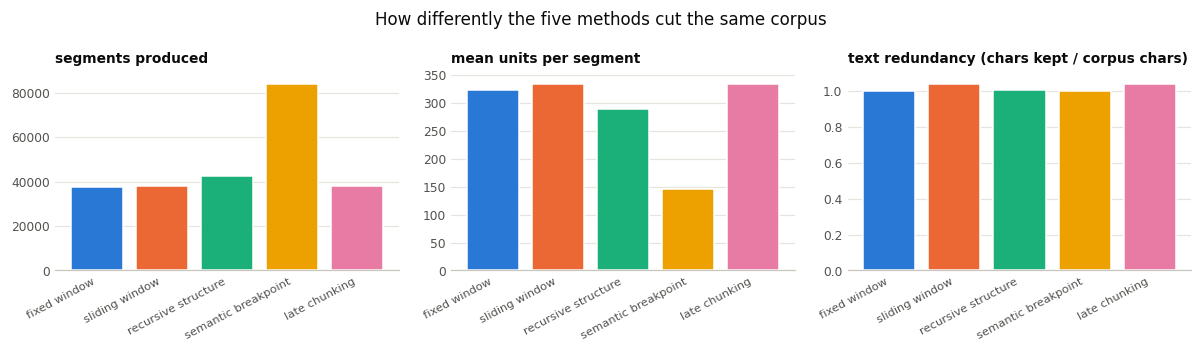

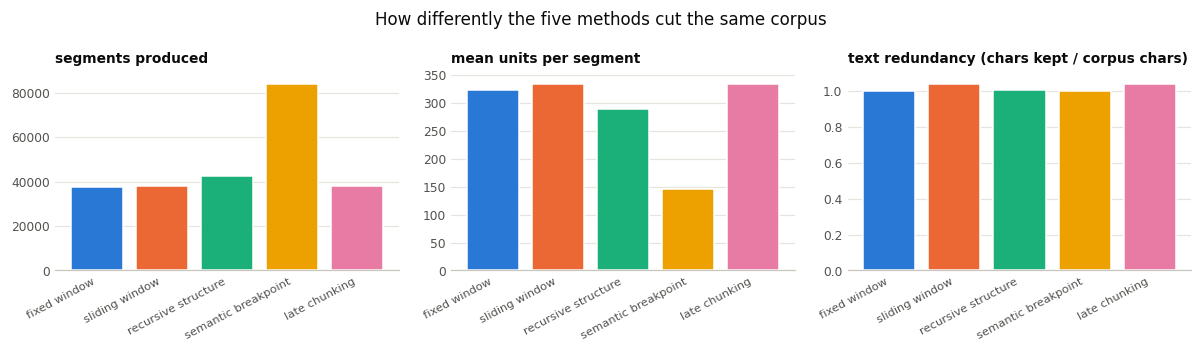

In [14]:
stats_rows = []
for m in C.CFG.CHUNK_METHODS:
    s = C.chunk_statistics(ds, chunk_tables[m])
    s['method'] = m
    s['chunking_s'] = timings[m]['chunking_s']
    stats_rows.append(s)
chunk_stats = pd.DataFrame(stats_rows)[
    ['method', 'chunks', 'chunks_per_doc', 'mean_units', 'median_units',
     'p10_units', 'p90_units', 'redundancy', 'chunking_s']]
display(chunk_stats.round(3))
C.save_table(chunk_stats, 'rq1_chunk_statistics')
C.plot_chunk_profile(chunk_stats, 'fig_rq1_chunk_statistics',
    caption='Segment statistics for the five chunking methods over all 28,482 candidate '
            'Technotes. Redundancy is the total segmented text divided by the corpus text, '
            'so a value above 1.0 is the cost of overlap.')

## 6. Embeddings

BGE-small over every chunk of the first four methods, plus every question. Chunks are embedded in length-sorted batches, which collapses padding and is several times faster than the natural order. Vectors are cached as float16, so re-running this notebook is a disk read.

In [15]:
encoder = C.get_encoder()
for m in ['fixed_window', 'sliding_window', 'recursive_structure', 'semantic_breakpoint']:
    texts = C.chunk_texts(ds, chunk_tables[m])
    emb, secs = C.cached_embeddings(m, lambda t=texts: C.encode_texts(encoder, t, batch_size=256),
                                    expected_rows=len(texts))
    timings[m]['embedding_s'] = secs
    print(f'{m:<24} {emb.shape}  {secs:6.0f}s')

qvec, qs = C.encode_queries(ds)
print('queries', qvec.shape, f'{qs:.0f}s')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

fixed_window             (37711, 384)     182s
sliding_window           (38046, 384)     193s
recursive_structure      (42409, 384)     195s
semantic_breakpoint      (83962, 384)     295s
queries (910, 384) 1s


### Late chunking

Late chunking cannot run on BGE-small, whose window is 512 sub-word tokens - the whole point is to encode the entire Technote first. It therefore uses a long-context encoder.

**This is why the matched control exists.** Comparing late chunking on a long-context encoder against sliding window on BGE-small would confound the pooling strategy with the encoder. The control runs the *same* sliding-window boundaries through the *same* long-context encoder with ordinary pooling, so the late-chunking effect is isolated.

In [16]:
if BUILD_LATE_CHUNKING:
    long_encoder, long_name = None, None
    for name in C.CFG.LONG_CONTEXT_MODELS:
        try:
            long_encoder = C.get_encoder(name, max_seq_length=8192)
            long_name = name
            print('long-context encoder:', name)
            break
        except Exception as e:
            print(f'  {name} unavailable ({type(e).__name__}); trying the next')
    assert long_encoder is not None, 'no long-context encoder could be loaded'

    qlong, _ = C.cached_embeddings('queries_long',
        lambda: C.encode_texts(long_encoder, ds.queries, batch_size=32),
        expected_rows=len(ds.questions))

    tbl = chunk_tables['late_chunking']
    emb, secs = C.cached_embeddings('late_chunking',
        lambda: C.late_chunk_embeddings(ds, tbl, long_encoder), expected_rows=len(tbl))
    timings['late_chunking']['embedding_s'] = secs
    print(f'late_chunking            {emb.shape}  {secs:.0f}s')

    ctl = chunk_tables[C.CFG.LATE_CONTROL]
    texts = C.chunk_texts(ds, ctl)
    emb2, secs2 = C.cached_embeddings(C.CFG.LATE_CONTROL,
        lambda t=texts: C.encode_texts(long_encoder, t, batch_size=64), expected_rows=len(ctl))
    timings[C.CFG.LATE_CONTROL]['embedding_s'] = secs2
    print(f'{C.CFG.LATE_CONTROL:<24} {emb2.shape}  {secs2:.0f}s')
    C.save_results({'model': long_name, 'max_seq_length': 8192}, 'rq1_long_context_encoder')
    C.free_gpu()
else:
    print('skipped - notebook A will report late chunking as not executed')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/445k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.58M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

long-context encoder: nomic-ai/modernbert-embed-base
late_chunking            (38046, 768)  1650s
sliding_window_longctx   (38046, 768)  1908s
  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_long_context_encoder.json


## 7. Build-once summary

The indexing half of the deployment-cost profile: how long each method takes to segment and embed the corpus, and how large its index is.

In [17]:
cost_rows = []
for m in C.CFG.CHUNK_METHODS + [C.CFG.LATE_CONTROL]:
    t = timings.get(m, {})
    n = len(chunk_tables[m])
    f = C.PATHS.CACHE / f'emb_{m}.npy'
    cost_rows.append({'method': m, 'chunks': n,
                      'chunking_s': t.get('chunking_s', float('nan')),
                      'embedding_s': t.get('embedding_s', float('nan')),
                      'index_mb': f.stat().st_size / 1024**2 if f.exists() else float('nan')})
build_cost = pd.DataFrame(cost_rows)
display(build_cost.round(2))
C.save_table(build_cost, 'rq1_build_cost')
C.save_results({'timings': timings, 'provenance': C.stamp()}, 'rq1_build_once')
print('\nBuild complete. Notebooks A, B and C now run in minutes.')

,method,chunks,chunking_s,embedding_s,index_mb
0,fixed_window,37711,7.94,182.07,27.62
1,sliding_window,38046,7.85,193.40,27.87
2,recursive_structure,42409,16.95,194.81,31.06
3,semantic_breakpoint,83962,1371.94,294.67,61.50
4,late_chunking,38046,6.41,1649.91,55.73
5,sliding_window_longctx,38046,5.18,1908.23,55.73


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_build_cost.csv
  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_build_once.json

Build complete. Notebooks A, B and C now run in minutes.


---
## What to run next

1. **RQ1_A_Chunking_Method.ipynb** - the chunking factor (about 4 minutes)
2. **RQ1_B_Retrieval_Strategy.ipynb** - the retrieval factor (about 6 minutes)
3. **RQ1_C_Reranking.ipynb** - the reranking factor (about 10 minutes)
4. **RQ1_D_Generation_Profile.ipynb** - the generator in the loop (35-90 minutes)
5. **RQ1_E_Answer_RQ1.ipynb** - the main-effect ranking and the report section

A, B and C are independent of each other and can be run in any order.